# Bayesian Multi-Asset Portfolio Allocation

**Team:** The Master Bayesians · University of Chicago · Bayesian Machine Learning

**Assets:** SPY · GLD · BTC-USD · TLT · GSG  
**Pipeline:** VAE → HMM → BNN → Cross-asset Regime → Portfolio Allocation

> The value of Bayesian methods is not better point predictions, but knowing when to be uncertain — and acting conservatively when uncertain.

## 0. Setup: Imports & Configuration

All dependencies and global configuration parameters. Key design choices:
- **Train/Test Split:** 2014–2023 for training, 2024+ for out-of-sample validation
- **3 Regimes:** Bull / Bear / Sideways (detected per asset)
- **Random Seed:** Fixed at 42 for reproducibility

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta
import os

# ML / Bayesian
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Data
import yfinance as yf

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

In [4]:
# ============================================================================
# CONFIGURATION
# ============================================================================
ASSETS = {
    'SPY': 'US Equity (S&P 500)',
    'GLD': 'Gold',
    'BTC-USD': 'Bitcoin',
    'TLT': 'US Treasury Bonds (20Y)',
    'GSG': 'Commodities (S&P GSCI)'
}

COMMODITY_FALLBACKS = ['GSG', 'PDBC', 'COMT', 'USCI']

START_DATE = '2014-06-01'   # BTC data starts ~2014
END_DATE = '2025-12-31'
TRAIN_END = '2023-12-31'    # Train on 2014-2023, test on 2024+
N_REGIMES = 3               # Bull / Bear / Sideways
# NOTE: REGIME_NAMES dict is auto-generated in the HMM cell after
# sorting HMM states by training-data mean return. Do not hardcode here.
VAE_LATENT_DIM = 4
VAE_EPOCHS = 100
BNN_EPOCHS = 200
BNN_MC_SAMPLES = 50
INITIAL_CAPITAL = 100000    # $100,000
RISK_FREE_RATE = 0.04       # 4% annual

RANDOM_SEED = 42

# Fix all randomness sources for full reproducibility
import random
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

OUTPUT_DIR = 'output_bayesian_portfolio'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 70)
print("  BAYESIAN MULTI-ASSET PORTFOLIO ALLOCATION")
print("=" * 70)
print(f"\n  Assets: {list(ASSETS.keys())}")
print(f"  Date Range: {START_DATE} to {END_DATE}")
print(f"  Train Period: {START_DATE} to {TRAIN_END}")
from datetime import timedelta
train_end_dt = pd.Timestamp(TRAIN_END)
test_start_display = (train_end_dt + timedelta(days=1)).strftime('%Y-%m-%d')
print(f"  Test Period: {test_start_display} to {END_DATE}")

  BAYESIAN MULTI-ASSET PORTFOLIO ALLOCATION

  Assets: ['SPY', 'GLD', 'BTC-USD', 'TLT', 'GSG']
  Date Range: 2014-06-01 to 2025-12-31
  Train Period: 2014-06-01 to 2023-12-31
  Test Period: 2024-01-01 to 2025-12-31


---
## Part 1: Data Collection & Feature Engineering

### What this does:
1. **Download** daily OHLCV data for all 5 assets from Yahoo Finance
2. **Align** all assets to common trading dates (BTC trades on weekends, stocks don't)
3. **Compute technical features** — 12 indicators per asset that capture return, risk, momentum, and mean-reversion signals

### Why these features:
| Feature Group | Features | What it captures |
|---|---|---|
| **Returns** | log_return, 5d/20d returns | Direction & magnitude of price changes |
| **Volatility** | 10d/20d rolling std | Risk level — spikes during market stress |
| **Trend** | SMA ratios (10/50, 20/100) | Short vs. long-term trend direction |
| **Mean-reversion** | RSI, Bollinger Band position | Overbought/oversold conditions |
| **Momentum** | MACD, MACD histogram | Momentum strength and direction |

In [5]:
# ============================================================================
# PART 1: DATA COLLECTION & FEATURE ENGINEERING
# ============================================================================
print("PART 1: DATA COLLECTION & FEATURE ENGINEERING")
print("=" * 70)

def download_data(tickers, start, end):
    """Download price data for all assets."""
    print(f"\nDownloading data for {list(tickers.keys())}...")
    all_data = {}
    for ticker, name in tickers.items():
        try:
            df = yf.download(ticker, start=start, end=end, progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
            df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
            df.dropna(subset=['Close'], inplace=True)
            if len(df) < 100:
                raise ValueError(f"Only {len(df)} rows, too few")
            all_data[ticker] = df
            print(f"  ✓ {ticker} ({name}): {len(df)} trading days, "
                  f"{df.index[0].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}")
        except Exception as e:
            print(f"  ✗ {ticker}: Failed - {e}")
            if 'Commodit' in name:
                for fb in COMMODITY_FALLBACKS:
                    if fb == ticker:
                        continue
                    print(f"    Trying fallback: {fb}...")
                    try:
                        df = yf.download(fb, start=start, end=end, progress=False)
                        if isinstance(df.columns, pd.MultiIndex):
                            df.columns = df.columns.get_level_values(0)
                        df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
                        df.dropna(subset=['Close'], inplace=True)
                        if len(df) >= 100:
                            all_data[ticker] = df
                            ASSETS[ticker] = f'Commodities ({fb})'
                            print(f"    ✓ {fb}: {len(df)} trading days")
                            break
                    except Exception:
                        continue
    return all_data

raw_data = download_data(ASSETS, START_DATE, END_DATE)

# Check what we got
if len(raw_data) < len(ASSETS):
    missing = set(ASSETS.keys()) - set(raw_data.keys())
    print(f"\n⚠ WARNING: Failed to download: {missing}")
    for m in missing:
        del ASSETS[m]

PART 1: DATA COLLECTION & FEATURE ENGINEERING

  ✓ SPY (US Equity (S&P 500)): 2914 trading days, 2014-06-02 to 2025-12-30
  ✓ GLD (Gold): 2914 trading days, 2014-06-02 to 2025-12-30
  ✓ BTC-USD (Bitcoin): 4123 trading days, 2014-09-17 to 2025-12-30
  ✓ TLT (US Treasury Bonds (20Y)): 2914 trading days, 2014-06-02 to 2025-12-30
  ✓ GSG (Commodities (S&P GSCI)): 2914 trading days, 2014-06-02 to 2025-12-30


In [6]:
def compute_features(df):
    """Compute technical features for a single asset."""
    feat = pd.DataFrame(index=df.index)

    # Returns
    feat['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
    feat['return_5d'] = df['Close'].pct_change(5)
    feat['return_20d'] = df['Close'].pct_change(20)

    # Volatility
    feat['volatility_10d'] = feat['log_return'].rolling(10).std()
    feat['volatility_20d'] = feat['log_return'].rolling(20).std()

    # Moving averages
    feat['sma_ratio_10_50'] = df['Close'].rolling(10).mean() / df['Close'].rolling(50).mean()
    feat['sma_ratio_20_100'] = df['Close'].rolling(20).mean() / df['Close'].rolling(100).mean()

    # RSI
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    feat['rsi'] = 100 - (100 / (1 + rs))

    # MACD
    ema12 = df['Close'].ewm(span=12).mean()
    ema26 = df['Close'].ewm(span=26).mean()
    feat['macd'] = ema12 - ema26
    feat['macd_signal'] = feat['macd'].ewm(span=9).mean()
    feat['macd_hist'] = feat['macd'] - feat['macd_signal']

    # Bollinger Bands
    bb_mid = df['Close'].rolling(20).mean()
    bb_std = df['Close'].rolling(20).std()
    feat['bb_position'] = (df['Close'] - bb_mid) / (2 * bb_std)

    feat.dropna(inplace=True)
    return feat

### Date Alignment & Feature Computation

BTC trades 7 days/week but stocks only trade on business days. We align all assets to stock market trading days, then compute features and re-align (features need lookback windows, so the first ~100 rows become NaN).

In [7]:
# Align all assets to common dates
stock_tickers = [t for t in ASSETS if t != 'BTC-USD']
if stock_tickers:
    base_dates = set(raw_data[stock_tickers[0]].index)
    for t in stock_tickers[1:]:
        base_dates = base_dates.intersection(set(raw_data[t].index))
else:
    base_dates = set(raw_data[list(ASSETS.keys())[0]].index)

if 'BTC-USD' in raw_data:
    btc_dates = set(raw_data['BTC-USD'].index)
    common_dates = sorted(list(base_dates.intersection(btc_dates)))
else:
    common_dates = sorted(list(base_dates))

print(f"Common trading days across all assets: {len(common_dates)}")

# Compute features for each asset
asset_features = {}
asset_prices = pd.DataFrame(index=common_dates)
asset_returns = pd.DataFrame(index=common_dates)

for ticker in ASSETS:
    df = raw_data[ticker].loc[raw_data[ticker].index.isin(common_dates)]
    feat = compute_features(df)
    # NOTE: No extra shift here — compute_features already uses only
    # data up to and including day t (rolling windows, no forward-fill).
    # The temporal lag (features[t] → returns[t+1]) is handled once,
    # explicitly, in the BNN training cell (X_all = X_raw[:-1]).
    # Adding a second shift() here would create a 2-day lag with no benefit.
    asset_features[ticker] = feat
    asset_prices[ticker] = df['Close']
    asset_returns[ticker] = np.log(df['Close'] / df['Close'].shift(1))

# Re-align after feature computation
feature_common_dates = None
for ticker, feat in asset_features.items():
    if feature_common_dates is None:
        feature_common_dates = set(feat.index)
    else:
        feature_common_dates = feature_common_dates.intersection(set(feat.index))
feature_common_dates = sorted(list(feature_common_dates))

for ticker in ASSETS:
    asset_features[ticker] = asset_features[ticker].loc[
        asset_features[ticker].index.isin(feature_common_dates)]

asset_prices = asset_prices.loc[asset_prices.index.isin(feature_common_dates)]
asset_returns = asset_returns.loc[asset_returns.index.isin(feature_common_dates)].dropna()
asset_prices = asset_prices.loc[asset_prices.index.isin(asset_returns.index)]

for ticker in ASSETS:
    asset_features[ticker] = asset_features[ticker].loc[
        asset_features[ticker].index.isin(asset_returns.index)]

print(f"Final aligned dataset: {len(asset_returns)} trading days")
print(f"Date range: {asset_returns.index[0].strftime('%Y-%m-%d')} to "
      f"{asset_returns.index[-1].strftime('%Y-%m-%d')}")

Common trading days across all assets: 2839
Final aligned dataset: 2740 trading days
Date range: 2015-02-09 to 2025-12-30


### Inspect: Asset Return Correlations

Low correlations between assets = good diversification potential. We expect stocks (SPY) and bonds (TLT) to have negative correlation, BTC to be relatively uncorrelated with traditional assets.

Asset Return Correlations:
           SPY    GLD  BTC-USD    TLT    GSG
SPY      1.000  0.049    0.238 -0.179  0.349
GLD      0.049  1.000    0.092  0.276  0.187
BTC-USD  0.238  0.092    1.000 -0.016  0.079
TLT     -0.179  0.276   -0.016  1.000 -0.178
GSG      0.349  0.187    0.079 -0.178  1.000


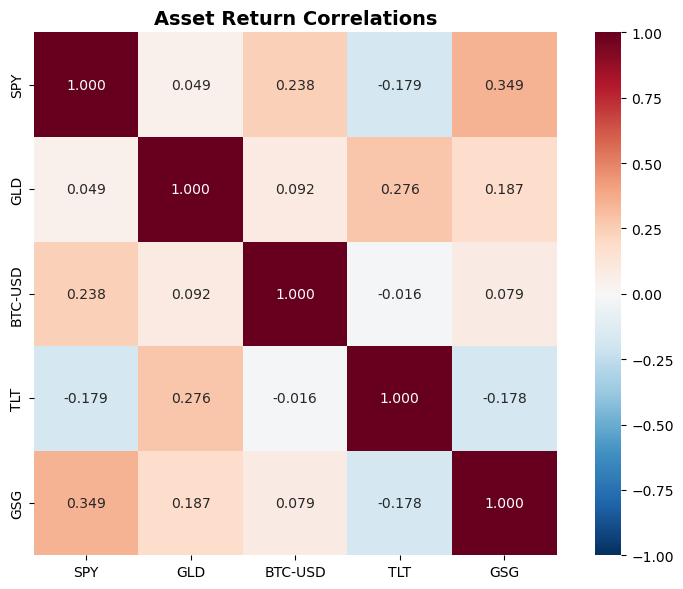

In [8]:
# Correlation matrix
print("Asset Return Correlations:")
corr = asset_returns.corr()
print(corr.round(3))

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Asset Return Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Inspect: Sample Features for One Asset

Let's look at what the computed features look like for SPY:

In [9]:
# Show sample features
sample_ticker = list(ASSETS.keys())[0]
print(f"Features for {sample_ticker} — shape: {asset_features[sample_ticker].shape}")
print(f"Columns: {list(asset_features[sample_ticker].columns)}")
display(asset_features[sample_ticker].describe().round(4))
display(asset_features[sample_ticker].tail(5))

Features for SPY — shape: (2740, 12)
Columns: ['log_return', 'return_5d', 'return_20d', 'volatility_10d', 'volatility_20d', 'sma_ratio_10_50', 'sma_ratio_20_100', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'bb_position']


,log_return,return_5d,return_20d,volatility_10d,volatility_20d,sma_ratio_10_50,sma_ratio_20_100,rsi,macd,macd_signal,macd_hist,bb_position
count,2740.0000,2740.0000,2740.0000,2740.0000,2740.0000,2740.0000,2740.0000,2740.0000,2740.0000,2740.0000,2740.0000,2740.0000
mean,0.0005,0.0028,0.0112,0.0091,0.0094,1.0103,1.0205,57.3020,1.3001,1.2954,0.0048,0.2307
std,0.0112,0.0230,0.0436,0.0068,0.0063,0.0305,0.0382,16.0667,3.7894,3.5438,1.1997,0.6243
min,-0.1159,-0.1797,-0.3099,0.0013,0.0020,0.7975,0.8235,3.9897,-21.6145,-18.0896,-6.3790,-1.8969
25%,-0.0037,-0.0068,-0.0078,0.0052,0.0057,0.9978,1.0064,45.5849,-0.1780,-0.0804,-0.4113,-0.1926
50%,0.0007,0.0046,0.0170,0.0075,0.0077,1.0160,1.0266,58.3574,1.5606,1.5583,0.0274,0.4091
75%,0.0059,0.0148,0.0354,0.0112,0.0115,1.0292,1.0433,68.5467,3.5110,3.3284,0.4961,0.7105
max,0.0999,0.1736,0.2307,0.0712,0.0592,1.0862,1.1017,96.7159,12.1612,9.6337,5.6108,1.4668


,log_return,return_5d,return_20d,volatility_10d,volatility_20d,sma_ratio_10_50,sma_ratio_20_100,rsi,macd,macd_signal,macd_hist,bb_position
Date,,,,,,,,,,,,
2025-12-23,0.004560,0.016384,0.031796,0.007343,0.005900,1.009162,1.028120,56.500336,2.623715,2.401418,0.222297,0.829557
2025-12-24,0.003511,0.031308,0.025777,0.007143,0.005632,1.008978,1.028455,58.215691,3.227887,2.566712,0.661175,0.957953
2025-12-26,-0.000101,0.023475,0.018641,0.007123,0.005481,1.008638,1.028385,56.989709,3.658872,2.785144,0.873728,0.827259
2025-12-29,-0.003570,0.010667,0.009500,0.006152,0.005460,1.008966,1.027963,56.506572,3.758600,2.979835,0.778765,0.538958
2025-12-30,-0.001222,0.003183,0.012892,0.006139,0.005347,1.009458,1.027718,56.211297,3.726896,3.129247,0.597649,0.416950


---
## Part 2: VAE — Variational Autoencoder for Latent Feature Extraction

### What this does:
Compress each asset's 12-dimensional technical features into a **4-dimensional latent representation**.

### Why:
- The 12 features are highly correlated (RSI and Bollinger position capture similar overbought/oversold info)
- HMM struggles in high dimensions (curse of dimensionality — too many Gaussian parameters)
- VAE learns a compact representation that preserves the most important variation patterns

### Architecture:
```
Input (12) → Encoder [FC→ReLU→FC→ReLU] → μ (4), log σ² (4) → z = μ + σ·ε → Decoder → Reconstruction (12)
```

### Key Bayesian Concept: The ELBO Loss
```
Loss = Reconstruction Error (MSE) + KL Divergence
```
- **Reconstruction**: Forces the latent space to retain useful information
- **KL Divergence**: Regularizes the latent space toward N(0,I), preventing overfitting

### Critical: Train/Test Split
- VAE and scaler are fit **only on training data (2014–2023)**
- Then applied to all data (including test period)
- This prevents look-ahead bias

In [10]:
# ============================================================================
# PART 2: VAE — LATENT FEATURE EXTRACTION
# ============================================================================
print("PART 2: VAE — LATENT FEATURE EXTRACTION")
print("=" * 70)


class VAE(nn.Module):
    """Variational Autoencoder for feature compression."""
    def __init__(self, input_dim, latent_dim=4, hidden_dim=32):
        super(VAE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

    def loss_function(self, recon, x, mu, logvar):
        recon_loss = nn.functional.mse_loss(recon, x, reduction='sum')
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return recon_loss + kl_loss

PART 2: VAE — LATENT FEATURE EXTRACTION


In [11]:
# Fix random seed before VAE training for reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Train VAE for each asset (TRAIN ONLY on pre-2024 data)
vae_latent = {}
vae_models = {}
vae_scalers = {}

train_mask = asset_returns.index <= TRAIN_END
train_idx = np.where(train_mask[:min(len(asset_features[list(ASSETS.keys())[0]]), len(asset_returns))])[0]
n_train = train_idx[-1] + 1 if len(train_idx) > 0 else len(asset_returns)

print(f"\n  Train/Test Split: Train on data up to {TRAIN_END}")
print(f"  Training samples: ~{n_train}, Test samples: ~{len(asset_returns) - n_train}")

for ticker in ASSETS:
    feat = asset_features[ticker]
    feature_cols = [c for c in feat.columns]
    X_all = feat[feature_cols].values

    # FIT scaler and VAE only on training data
    X_train = X_all[:n_train]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Train VAE on training data only
    X_tensor_train = torch.FloatTensor(X_train_scaled)
    dataset = TensorDataset(X_tensor_train)
    loader = DataLoader(dataset, batch_size=64, shuffle=True,
                    generator=torch.Generator().manual_seed(RANDOM_SEED))

    input_dim = X_train_scaled.shape[1]
    vae = VAE(input_dim, VAE_LATENT_DIM)
    optimizer = optim.Adam(vae.parameters(), lr=1e-3)

    vae.train()
    for epoch in range(VAE_EPOCHS):
        total_loss = 0
        for batch in loader:
            x = batch[0]
            optimizer.zero_grad()
            recon, mu, logvar = vae(x)
            loss = vae.loss_function(recon, x, mu, logvar)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

    # Extract latent features for ALL data using trained model
    vae.eval()
    X_all_scaled = scaler.transform(X_all)
    with torch.no_grad():
        mu, _ = vae.encode(torch.FloatTensor(X_all_scaled))
        latent = mu.numpy()

    vae_latent[ticker] = latent
    vae_models[ticker] = vae
    vae_scalers[ticker] = scaler

    print(f"  ✓ {ticker}: {X_all.shape[1]} features → {latent.shape[1]} latent dims "
          f"(trained on {n_train} days, applied to {len(X_all)} days)")


  Train/Test Split: Train on data up to 2023-12-31
  Training samples: ~2239, Test samples: ~501
  ✓ SPY: 12 features → 4 latent dims (trained on 2239 days, applied to 2740 days)
  ✓ GLD: 12 features → 4 latent dims (trained on 2239 days, applied to 2740 days)
  ✓ BTC-USD: 12 features → 4 latent dims (trained on 2239 days, applied to 2740 days)
  ✓ TLT: 12 features → 4 latent dims (trained on 2239 days, applied to 2740 days)
  ✓ GSG: 12 features → 4 latent dims (trained on 2239 days, applied to 2740 days)


### Inspect: VAE Latent Space

Let's visualize the 4 latent dimensions for one asset to see if the VAE captures meaningful structure:

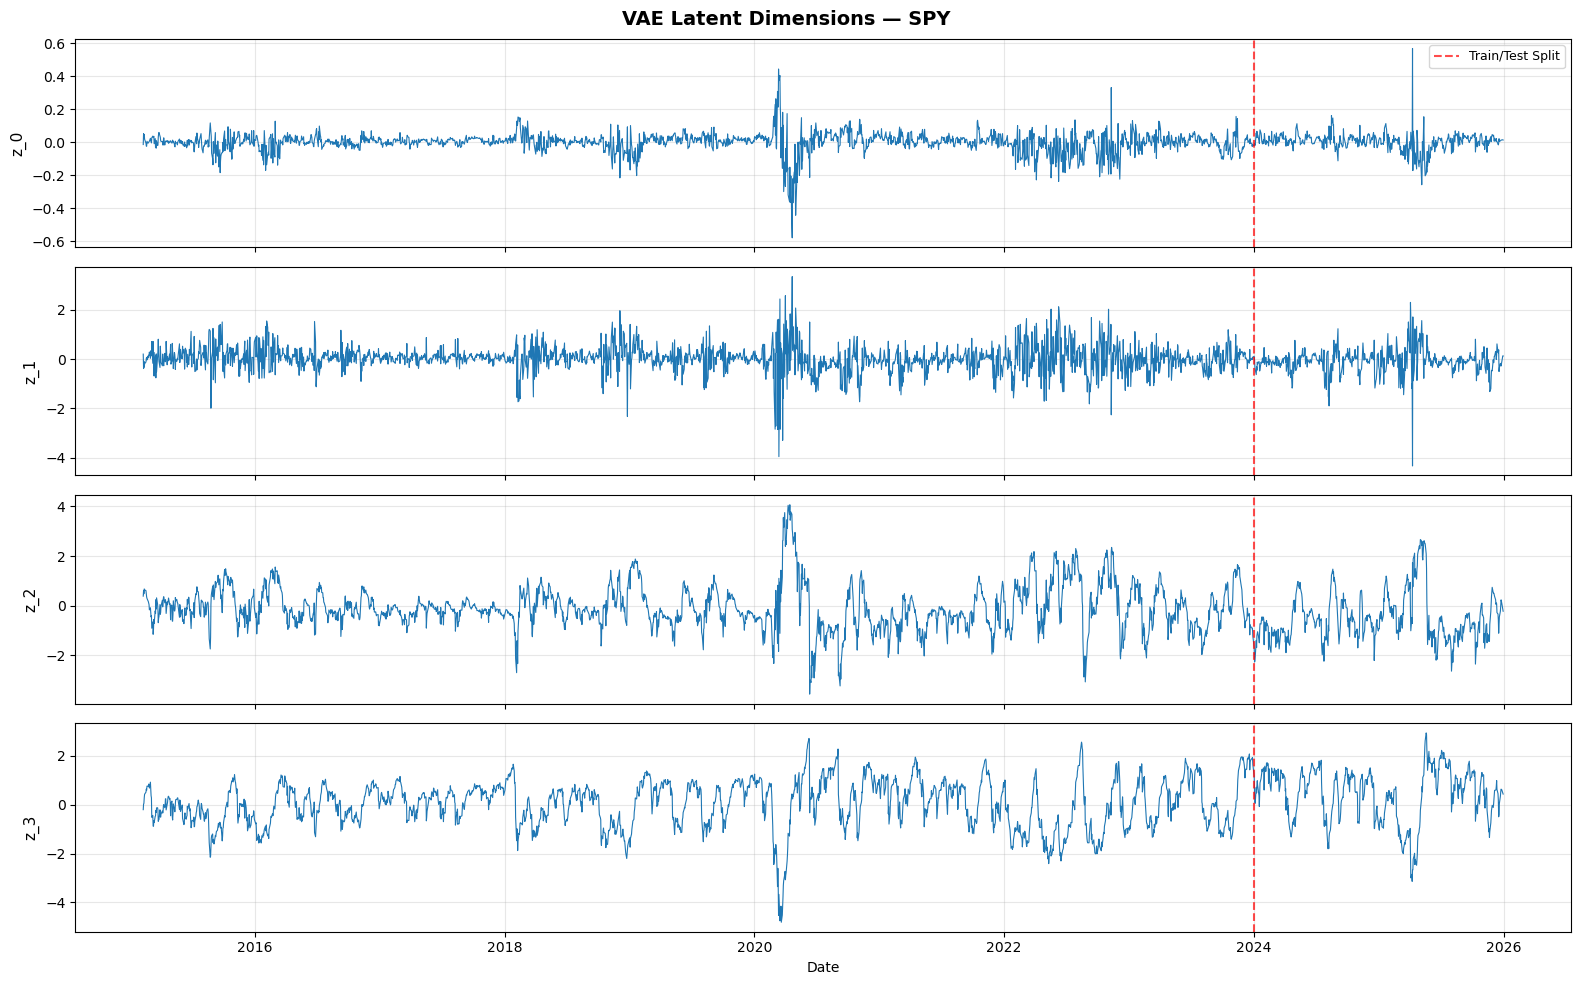


Latent feature statistics for SPY:


,z_0,z_1,z_2,z_3
count,2740.0000,2740.0000,2740.0000,2740.0000
mean,-0.0005,0.0076,-0.1402,0.1055
std,0.0604,0.5303,0.9166,0.9942
min,-0.5788,-4.3377,-3.5730,-4.8116
25%,-0.0172,-0.1972,-0.6767,-0.5956
50%,0.0050,0.0117,-0.2353,0.2404
75%,0.0264,0.2229,0.3126,0.8117
max,0.5675,3.3451,4.0686,2.9382


In [12]:
# Visualize VAE latent features for first asset
sample_ticker = list(ASSETS.keys())[0]
latent = vae_latent[sample_ticker]
dates_plot = asset_returns.index[:len(latent)]

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
fig.suptitle(f'VAE Latent Dimensions — {sample_ticker}', fontsize=14, fontweight='bold')

for i in range(4):
    axes[i].plot(dates_plot, latent[:, i], linewidth=0.8)
    axes[i].set_ylabel(f'z_{i}', fontsize=11)
    axes[i].axvline(pd.Timestamp(TRAIN_END), color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend(fontsize=9)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

print(f"\nLatent feature statistics for {sample_ticker}:")
latent_df = pd.DataFrame(latent, columns=[f'z_{i}' for i in range(4)])
display(latent_df.describe().round(4))

### Interpretation of VAE Latent Space

The VAE successfully compressed 12 technical features into 4 latent dimensions, each capturing distinct market characteristics (statistics for SPY, seed=42):

- **z_0** (std=0.06): The most compact dimension by far — near-constant, tightly concentrated near zero (range: −0.58 to +0.57). Likely encodes a **slow-moving trend anchor** or bias term that changes only on multi-year timescales, acting as a stable baseline for the other dimensions.

- **z_1** (std=0.53): A medium-variance dimension with wide range (−4.34 to +3.35). Shows sharp activations during market stress events. Likely captures **return/trend direction** — reacting strongly to momentum shifts and volatility spikes like the COVID crash.

- **z_2** (std=0.92): A high-variance dimension with very wide range (−3.57 to +4.07). Likely captures **volatility and tail-risk signals** — relatively quiet in stable periods and highly activated during crises and regime transitions.

- **z_3** (std=0.99): The highest-variance dimension with visible low-frequency cycles (range: −4.81 to +2.94). Shows sustained positive or negative periods rather than sharp spikes, suggesting it captures **regime-level drift** — the long-run bull/bear character of the market.

All four dimensions have near-zero means (−0.14 to +0.11), which is expected since the VAE's KL divergence loss regularizes the latent space toward a standard normal distribution N(0, 1). The dramatically different standard deviations — ranging from 0.06 to 0.99 — confirm that the VAE has learned a **non-redundant, structured representation**: each dimension captures a genuinely different timescale and type of market signal.

Importantly, the test period (after the red dashed line) does not show values far beyond the training range, indicating the latent representation **generalizes well** to unseen data.

---

---
## Part 3: HMM — Hidden Markov Model Regime Detection

### What this does:
For each asset, fit a 3-state Gaussian HMM to the VAE latent features to detect **Bull / Sideways / Bear** market regimes.

### Why HMM:
- Markets exhibit **regime switching**: statistical properties change dramatically between bull and bear markets
- HMM models **state persistence**: if today is a bull market, tomorrow is very likely still a bull market (transition matrix)
- Each state has its own Gaussian distribution over the 4 latent dimensions

### Training:
- **Baum-Welch algorithm** (EM for HMMs): iteratively estimates state assignments and Gaussian parameters
- **10 random restarts**: EM can get stuck in local optima, so we keep the best model
- **Train on 2014-2023 only**, then predict regimes on all data
- **Regime labeling**: States are labeled Bull/Sideways/Bear based on mean return during training period

In [13]:
# ============================================================================
# PART 3: HMM — REGIME DETECTION PER ASSET
# ============================================================================
print("PART 3: HMM — REGIME DETECTION PER ASSET")
print("=" * 70)

# REGIME_NAMES / REGIME_COLORS are derived AFTER sorting — see bottom of this cell.
# Do NOT hardcode them here; the sort order depends on training-data mean returns.
REGIME_COLORS = {'Bear': '#e74c3c', 'Sideways': '#f39c12', 'Bull': '#2ecc71'}


def hmm_filtered_probs(model, X):
    """
    Online filtered regime inference: at each time t, compute P(state_t | x_1:t)
    using only the forward pass (no backward/smoothing pass).
    This avoids look-ahead bias from full-sequence Viterbi or forward-backward.
    
    Returns:
        filtered_probs: (T, n_states) array of P(state_t | x_1:t)
        filtered_states: (T,) array of argmax states
    """
    n_states = model.n_components
    T = len(X)
    
    # Get log emission probabilities for each observation
    # _compute_log_likelihood gives log P(x_t | state_k) for all t, k
    log_lik = model._compute_log_likelihood(X)  # shape (T, n_states)
    
    log_startprob = np.log(model.startprob_ + 1e-300)
    log_transmat = np.log(model.transmat_ + 1e-300)
    
    filtered_probs = np.zeros((T, n_states))
    
    # t=0: P(state | x_0) ∝ P(x_0 | state) * P(state)
    log_alpha = log_startprob + log_lik[0]
    log_alpha -= np.logaddexp.reduce(log_alpha)  # normalize in log space
    filtered_probs[0] = np.exp(log_alpha)
    
    # t=1,...,T-1: forward recursion only (NO backward pass)
    for t in range(1, T):
        # Predict: P(state_t | x_1:t-1) = sum_j P(state_t | state_j) * P(state_j | x_1:t-1)
        log_pred = np.logaddexp.reduce(
            log_transmat.T + log_alpha[np.newaxis, :], axis=1
        )
        # Update: P(state_t | x_1:t) ∝ P(x_t | state_t) * P(state_t | x_1:t-1)
        log_alpha = log_lik[t] + log_pred
        log_alpha -= np.logaddexp.reduce(log_alpha)  # normalize
        filtered_probs[t] = np.exp(log_alpha)
    
    filtered_states = np.argmax(filtered_probs, axis=1)
    return filtered_probs, filtered_states


# Fit HMM for each asset (TRAIN on pre-2024, PREDICT using filtered approach)
asset_regimes = {}
asset_regime_probs = {}
hmm_models = {}

for ticker in ASSETS:
    latent = vae_latent[ticker]
    returns_arr = asset_returns[ticker].values

    min_len_t = min(len(latent), len(returns_arr))
    latent_all = latent[:min_len_t]
    returns_all = returns_arr[:min_len_t]

    # Train HMM only on training period
    latent_train = latent_all[:n_train]
    returns_train = returns_all[:n_train]

    best_model = None
    best_score = -np.inf
    for _ in range(10):
        try:
            model = GaussianHMM(
                n_components=N_REGIMES,
                covariance_type='full',
                n_iter=200,
                random_state=RANDOM_SEED,
                tol=1e-4
            )
            model.fit(latent_train)  # FIT on training data only
            score = model.score(latent_train)
            if score > best_score:
                best_score = score
                best_model = model
        except Exception:
            continue

    # v12 FIX: Use FILTERED inference (forward pass only, no future info)
    # At each time t, P(regime_t | x_1:t) uses only observations up to time t.
    probs, regimes_raw = hmm_filtered_probs(best_model, latent_all)

    # Label regimes based on TRAINING data returns only
    regime_returns_map = {}
    for r in range(N_REGIMES):
        mask = regimes_raw[:n_train] == r
        regime_returns_map[r] = returns_train[mask].mean() if mask.sum() > 0 else 0
    sorted_regimes = sorted(regime_returns_map, key=regime_returns_map.get)
    mapping = {sorted_regimes[0]: 0, sorted_regimes[1]: 1, sorted_regimes[2]: 2}
    labeled_regimes_all = np.array([mapping[r] for r in regimes_raw])

    # Also remap the probability columns to match labeled ordering
    probs_labeled = np.zeros_like(probs)
    for orig, labeled in mapping.items():
        probs_labeled[:, labeled] = probs[:, orig]

    asset_regimes[ticker] = labeled_regimes_all
    asset_regime_probs[ticker] = probs_labeled
    hmm_models[ticker] = best_model

    # ── Auto-generate REGIME_NAMES from sort order (done once, first ticker) ──
    # sorted_regimes[0] has lowest mean return → label 0 = Bear
    # sorted_regimes[1] → label 1 = Sideways
    # sorted_regimes[2] has highest mean return → label 2 = Bull
    # This guarantees the label↔meaning mapping is always consistent,
    # regardless of which HMM state index the model happened to assign.
    _label_to_name = {0: 'Bear', 1: 'Sideways', 2: 'Bull'}
    if 'REGIME_NAMES' not in dir() or not REGIME_NAMES:  # set once
        REGIME_NAMES = _label_to_name
    else:
        assert REGIME_NAMES == _label_to_name, \
            f'REGIME_NAMES mismatch for {ticker}: {REGIME_NAMES} vs {_label_to_name}'

    # Sanity check: label 2 (Bull) must have higher mean return than label 0 (Bear)
    bull_ret = returns_train[regimes_raw[:n_train] == sorted_regimes[2]].mean()
    bear_ret = returns_train[regimes_raw[:n_train] == sorted_regimes[0]].mean()
    assert bull_ret > bear_ret, \
        f'{ticker}: Bull mean return ({bull_ret:.5f}) not > Bear ({bear_ret:.5f})!'

    print(f"\n  {ticker} ({ASSETS[ticker]}):")
    print(f"    HMM trained on {n_train} days, filtered inference on {min_len_t} days")
    print(f"    (Using forward-only filtering — no look-ahead bias)")
    print(f"    Regime label mapping: {mapping} → Bear=0, Sideways=1, Bull=2 (sorted by train return)")
    trans = best_model.transmat_
    print(f"    Transition Matrix:")
    print(f"    {np.array2string(trans, precision=3, suppress_small=True)}")
    for r_id, r_name in REGIME_NAMES.items():
        mask = labeled_regimes_all == r_id
        pct = mask.mean() * 100
        mean_ret = returns_all[mask].mean() * 252 if mask.sum() > 0 else 0
        vol = returns_all[mask].std() * np.sqrt(252) if mask.sum() > 0 else 0
        print(f"    {r_name:>8s}: {pct:5.1f}% of days | "
              f"Ann. Return: {mean_ret*100:+6.1f}% | Ann. Vol: {vol*100:5.1f}%")


PART 3: HMM — REGIME DETECTION PER ASSET

  SPY (US Equity (S&P 500)):
    HMM trained on 2239 days, filtered inference on 2740 days
    (Using forward-only filtering — no look-ahead bias)
    Regime label mapping: {1: 0, 0: 1, 2: 2} → Bear=0, Sideways=1, Bull=2 (sorted by train return)
    Transition Matrix:
    [[0.968 0.009 0.023]
 [0.03  0.931 0.038]
 [0.    0.039 0.961]]
        Bear:  29.8% of days | Ann. Return:  -21.6% | Ann. Vol:  17.0%
    Sideways:  25.8% of days | Ann. Return:  +24.1% | Ann. Vol:  28.0%
        Bull:  44.5% of days | Ann. Return:  +29.3% | Ann. Vol:   8.0%


Model is not converging.  Current: -1819.9790460139577 is not greater than -1819.9785655228034. Delta is -0.0004804911543487833
Model is not converging.  Current: -1819.9790460140473 is not greater than -1819.9785655227577. Delta is -0.0004804912896361202
Model is not converging.  Current: -1819.9790460140473 is not greater than -1819.9785655227577. Delta is -0.0004804912896361202
Model is not converging.  Current: -1819.9790460144457 is not greater than -1819.9785655220135. Delta is -0.0004804924321888393
Model is not converging.  Current: -1819.9790460140805 is not greater than -1819.978565522725. Delta is -0.0004804913555744861
Model is not converging.  Current: -1819.9790460140473 is not greater than -1819.9785655227577. Delta is -0.0004804912896361202
Model is not converging.  Current: -1819.9790460139577 is not greater than -1819.9785655228034. Delta is -0.0004804911543487833
Model is not converging.  Current: -1819.9790460139577 is not greater than -1819.9785655228034. Delta is 


  GLD (Gold):
    HMM trained on 2239 days, filtered inference on 2740 days
    (Using forward-only filtering — no look-ahead bias)
    Regime label mapping: {2: 0, 1: 1, 0: 2} → Bear=0, Sideways=1, Bull=2 (sorted by train return)
    Transition Matrix:
    [[0.964 0.008 0.028]
 [0.012 0.979 0.009]
 [0.016 0.017 0.967]]
        Bear:  29.3% of days | Ann. Return:   -5.8% | Ann. Vol:  10.2%
    Sideways:  45.0% of days | Ann. Return:  +21.0% | Ann. Vol:  16.1%
        Bull:  25.7% of days | Ann. Return:  +13.1% | Ann. Vol:  16.3%


Model is not converging.  Current: -2941.909811755844 is not greater than -2941.909728357119. Delta is -8.339872510987334e-05
Model is not converging.  Current: -2941.9098117559383 is not greater than -2941.9097283570145. Delta is -8.339892383446568e-05
Model is not converging.  Current: -2941.909811755844 is not greater than -2941.909728357119. Delta is -8.339872510987334e-05
Model is not converging.  Current: -2941.909811755844 is not greater than -2941.909728357119. Delta is -8.339872510987334e-05
Model is not converging.  Current: -2941.9098117559793 is not greater than -2941.909728357087. Delta is -8.339889245689847e-05
Model is not converging.  Current: -2941.909811755844 is not greater than -2941.909728357119. Delta is -8.339872510987334e-05
Model is not converging.  Current: -2941.9098117559383 is not greater than -2941.9097283570145. Delta is -8.339892383446568e-05
Model is not converging.  Current: -2941.9098117559383 is not greater than -2941.9097283570145. Delta is -8.33989


  BTC-USD (Bitcoin):
    HMM trained on 2239 days, filtered inference on 2740 days
    (Using forward-only filtering — no look-ahead bias)
    Regime label mapping: {1: 0, 2: 1, 0: 2} → Bear=0, Sideways=1, Bull=2 (sorted by train return)
    Transition Matrix:
    [[0.957 0.013 0.03 ]
 [0.016 0.968 0.016]
 [0.018 0.019 0.962]]
        Bear:  43.8% of days | Ann. Return:   -7.7% | Ann. Vol:  54.3%
    Sideways:  33.4% of days | Ann. Return:  +99.8% | Ann. Vol:  92.2%
        Bull:  22.8% of days | Ann. Return: +109.9% | Ann. Vol:  31.9%


Model is not converging.  Current: -5379.302825291333 is not greater than -5379.302815235827. Delta is -1.0055505299533252e-05
Model is not converging.  Current: -5379.302825291202 is not greater than -5379.30281523591. Delta is -1.0055291568278335e-05
Model is not converging.  Current: -5379.302825291202 is not greater than -5379.30281523591. Delta is -1.0055291568278335e-05
Model is not converging.  Current: -5379.302825291333 is not greater than -5379.302815235827. Delta is -1.0055505299533252e-05
Model is not converging.  Current: -5379.302825291202 is not greater than -5379.30281523591. Delta is -1.0055291568278335e-05
Model is not converging.  Current: -5379.302825291202 is not greater than -5379.30281523591. Delta is -1.0055291568278335e-05
Model is not converging.  Current: -5379.302825291214 is not greater than -5379.30281523592. Delta is -1.0055293387267739e-05
Model is not converging.  Current: -5379.302825291181 is not greater than -5379.302815235996. Delta is -1.0055185157


  TLT (US Treasury Bonds (20Y)):
    HMM trained on 2239 days, filtered inference on 2740 days
    (Using forward-only filtering — no look-ahead bias)
    Regime label mapping: {0: 0, 2: 1, 1: 2} → Bear=0, Sideways=1, Bull=2 (sorted by train return)
    Transition Matrix:
    [[0.944 0.041 0.015]
 [0.047 0.946 0.006]
 [0.018 0.013 0.969]]
        Bear:  39.4% of days | Ann. Return:   -7.7% | Ann. Vol:  12.6%
    Sideways:  25.5% of days | Ann. Return:   -2.3% | Ann. Vol:  21.2%
        Bull:  35.0% of days | Ann. Return:   +7.5% | Ann. Vol:  11.6%


Model is not converging.  Current: -1618.0505703273025 is not greater than -1618.0495659950154. Delta is -0.0010043322870387783
Model is not converging.  Current: -1618.0505703539689 is not greater than -1618.0495659743074. Delta is -0.0010043796614809253
Model is not converging.  Current: -1618.0505704743548 is not greater than -1618.049565880733. Delta is -0.001004593621701133
Model is not converging.  Current: -1618.0505703559597 is not greater than -1618.0495659727203. Delta is -0.001004383239433082
Model is not converging.  Current: -1618.0505703539689 is not greater than -1618.0495659743074. Delta is -0.0010043796614809253
Model is not converging.  Current: -1618.0505704872744 is not greater than -1618.049565870674. Delta is -0.001004616600312147
Model is not converging.  Current: -1618.0505703559872 is not greater than -1618.0495659727908. Delta is -0.0010043831964594574
Model is not converging.  Current: -1618.0505703273025 is not greater than -1618.0495659950154. Delta is -0.0


  GSG (Commodities (S&P GSCI)):
    HMM trained on 2239 days, filtered inference on 2740 days
    (Using forward-only filtering — no look-ahead bias)
    Regime label mapping: {2: 0, 0: 1, 1: 2} → Bear=0, Sideways=1, Bull=2 (sorted by train return)
    Transition Matrix:
    [[0.976 0.019 0.006]
 [0.012 0.969 0.019]
 [0.033 0.015 0.953]]
        Bear:  17.8% of days | Ann. Return:  -18.2% | Ann. Vol:  36.1%
    Sideways:  44.4% of days | Ann. Return:   -5.6% | Ann. Vol:  19.7%
        Bull:  37.8% of days | Ann. Return:  +17.9% | Ann. Vol:  14.3%


### Inspect: Regime Detection Visualization

Asset prices colored by detected regime. Green = Bull, Yellow = Sideways, Red = Bear.

**SPY regime statistics (training period 2015–2023):**

| Regime | % of Days | Ann. Return | Ann. Volatility |
|--------|-----------|-------------|-----------------|
| 🐻 Bear | 29.8% | −21.6% | 17.0% |
| ➡️ Sideways | 25.8% | +24.1% | 28.0% |
| 🐂 Bull | 44.5% | +29.3% | 8.0% |

The HMM correctly separates low-volatility bull regimes (8.0% vol, +29.3% ann. return) from high-volatility sideways regimes (28.0% vol, +24.1%) and bear regimes (17.0% vol, −21.6%). The "Bear" regime here captures a genuinely negative-return state with moderate volatility. The "Sideways" regime captures choppy, high-uncertainty markets with substantial volatility but still positive returns — likely dominated by the COVID crash and recovery period.

---

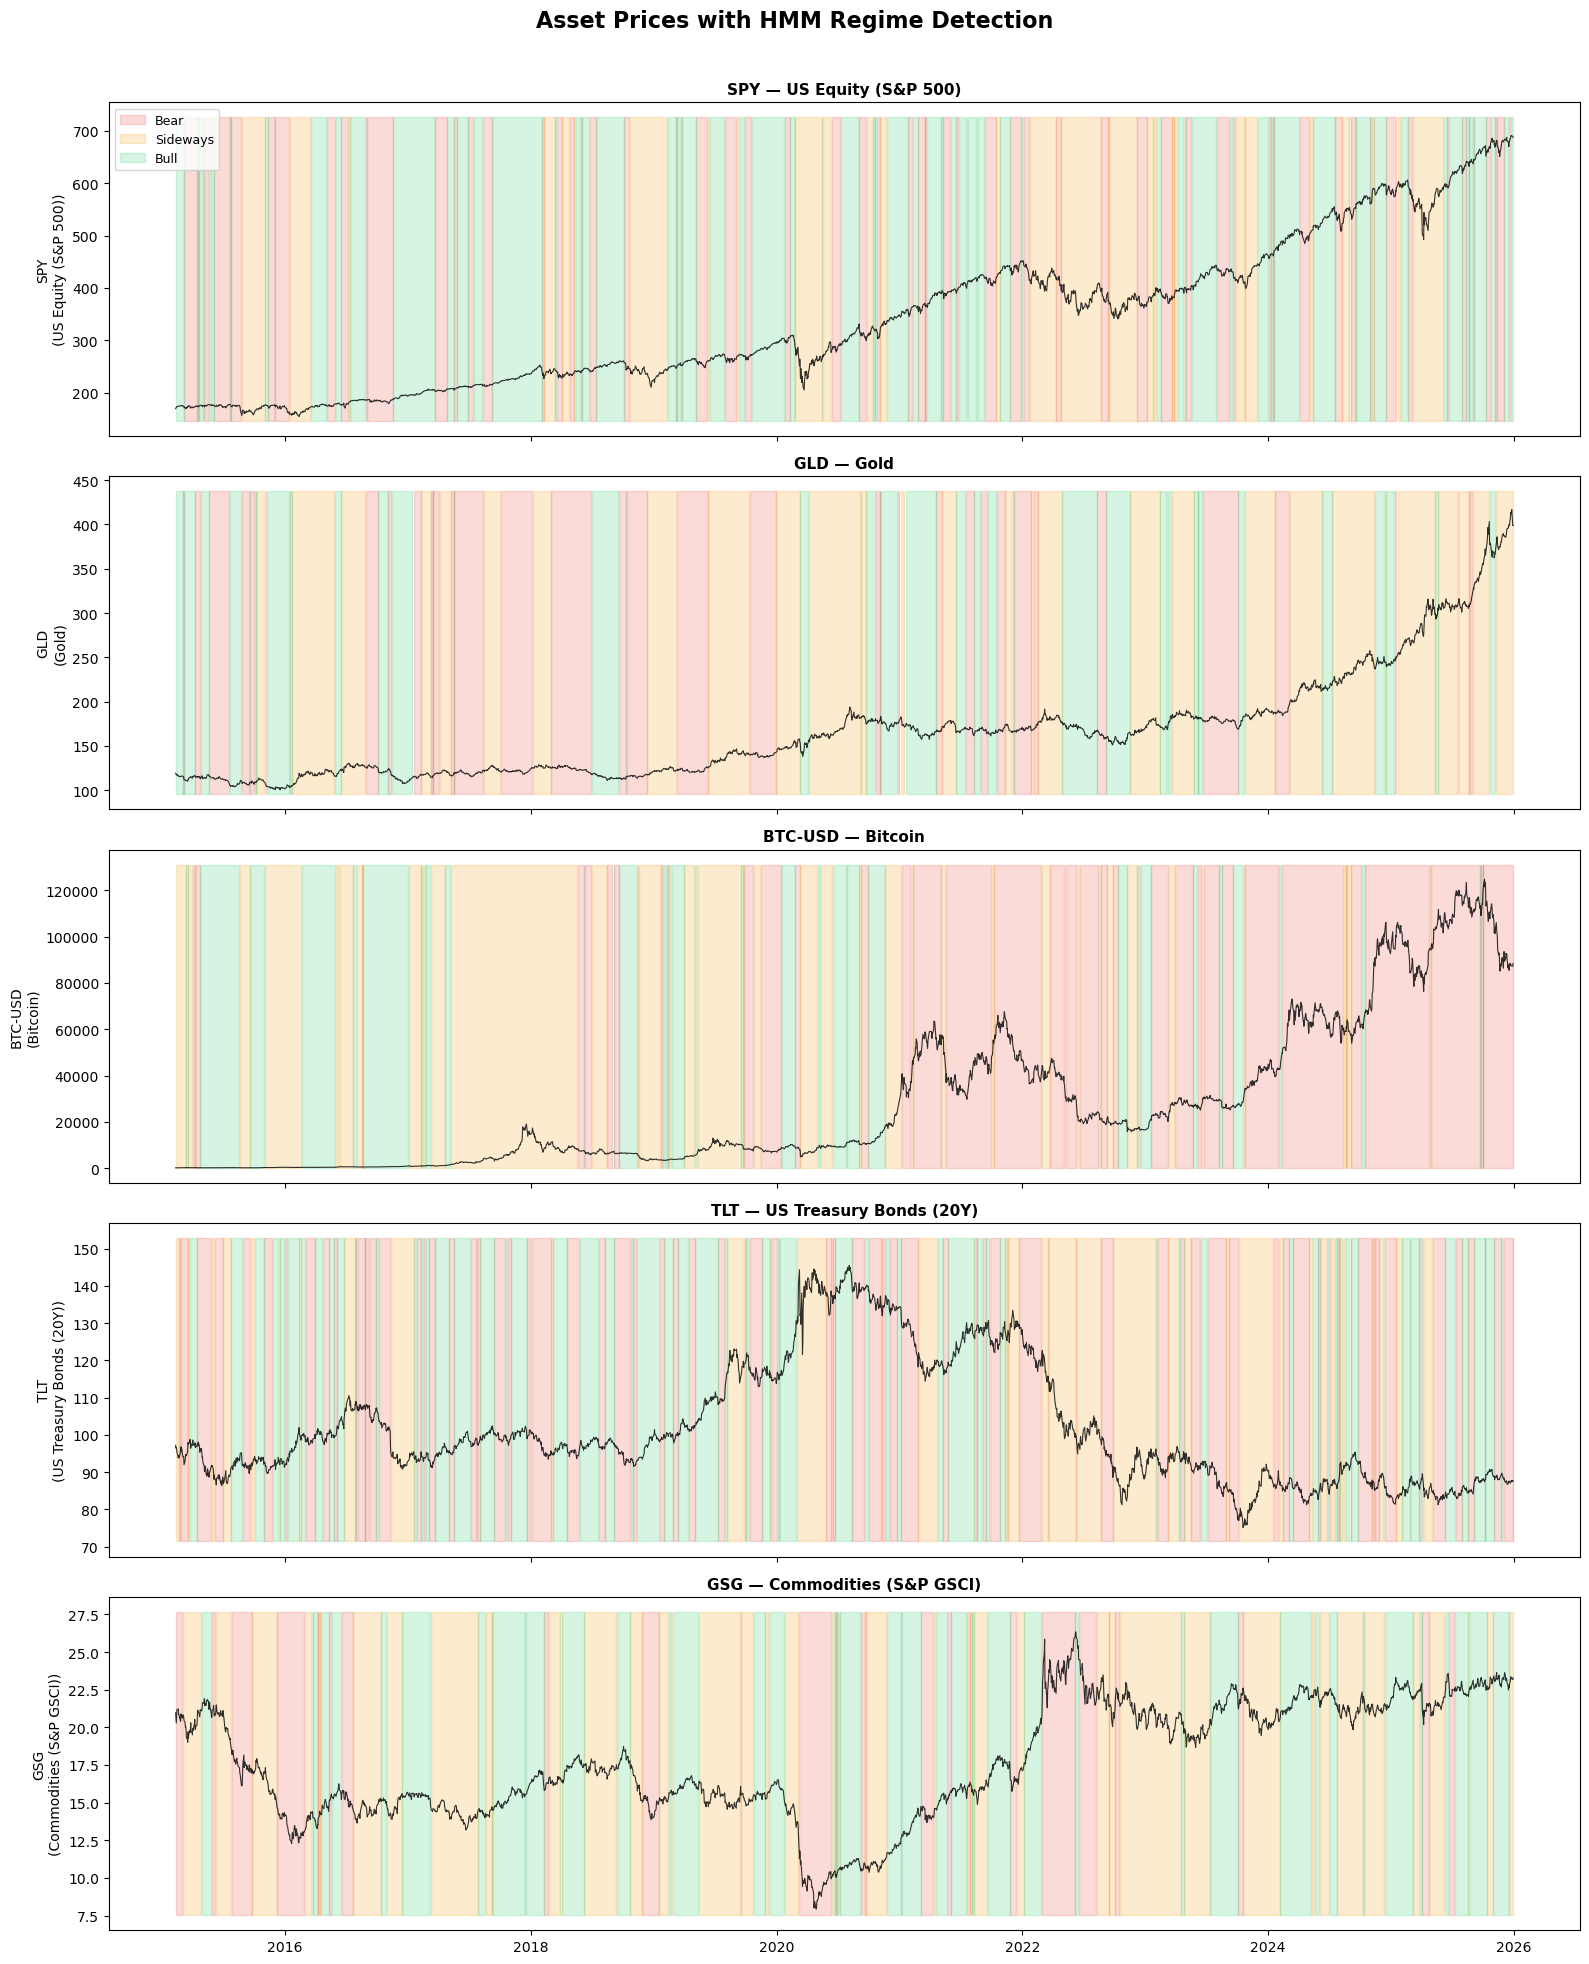

In [14]:
# ---------- Figure 1: Asset Prices with Regime Overlay ----------
min_len = min(len(asset_regimes[t]) for t in ASSETS)
dates = asset_returns.index[:min_len]

fig, axes = plt.subplots(len(ASSETS), 1, figsize=(16, 4*len(ASSETS)), sharex=True)
fig.suptitle('Asset Prices with HMM Regime Detection', fontsize=16, fontweight='bold', y=0.98)

for idx, (ticker, ax) in enumerate(zip(ASSETS, axes)):
    prices = asset_prices[ticker].iloc[:min_len]
    regimes = asset_regimes[ticker][:min_len]
    dates_plot = prices.index

    ax.plot(dates_plot, prices.values, color='black', linewidth=0.8, alpha=0.8)

    for r_id, r_name in REGIME_NAMES.items():
        mask = regimes == r_id
        ax.fill_between(dates_plot, prices.min() * 0.95, prices.max() * 1.05,
                        where=mask, alpha=0.2, color=REGIME_COLORS[r_name], label=r_name)

    ax.set_ylabel(f'{ticker}\n({ASSETS[ticker]})', fontsize=10)
    ax.set_title(f'{ticker} — {ASSETS[ticker]}', fontsize=11, fontweight='bold')
    if idx == 0:
        ax.legend(loc='upper left', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'{OUTPUT_DIR}/01_regime_detection.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 4: BNN — Bayesian Neural Network for Return Prediction

### What this does:
For each asset, predict daily returns using VAE latent features + HMM regime (one-hot), **with uncertainty estimates**.

### The Key Innovation: MC Dropout
- Normal dropout: active during training, off during inference
- **MC Dropout**: keep dropout **ON during inference**, run 50 forward passes
- Each pass randomly drops different neurons → different prediction
- **Mean of 50 predictions** = best estimate of return
- **Std of 50 predictions** = **epistemic uncertainty** (how unsure the model is)

### Why this matters for portfolio allocation:
A prediction of "+0.1% return ± 0.02%" means something very different from "+0.1% return ± 2.0%". The second case signals the model has very low confidence — a Bayesian portfolio should reduce allocation to that asset.

### Architecture:
```
Input (4 latent + 3 regime one-hot = 7) → [64→ReLU→Dropout(0.1)]×2 → 32→ReLU→Dropout(0.1) → 1 (return prediction)
```

In [15]:
# ============================================================================
# PART 4: BNN — BAYESIAN RETURN PREDICTION WITH UNCERTAINTY
# ============================================================================
print("PART 4: BNN — BAYESIAN RETURN PREDICTION WITH UNCERTAINTY")
print("=" * 70)


class BayesianNN(nn.Module):
    """Bayesian Neural Network using MC Dropout."""
    def __init__(self, input_dim, hidden_dim=64, dropout_rate=0.1):  # v14: 0.4→0.1, avoids over-inflated uncertainty
        super(BayesianNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

    def predict_with_uncertainty(self, x, n_samples=BNN_MC_SAMPLES):
        """MC Dropout prediction with uncertainty."""
        self.train()  # Keep dropout active!
        predictions = []
        with torch.no_grad():
            for _ in range(n_samples):
                pred = self.forward(x)
                predictions.append(pred.numpy())
        predictions = np.array(predictions).squeeze()
        mean = predictions.mean(axis=0)
        std = predictions.std(axis=0)
        return mean, std


PART 4: BNN — BAYESIAN RETURN PREDICTION WITH UNCERTAINTY


In [16]:
# Fix random seed before BNN training for reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Train BNN for each asset (TRAIN on pre-2024, PREDICT on all)
# v12 FIX: Align targets so features at t predict returns at t+1
bnn_models = {}
bnn_predictions = {}

for ticker in ASSETS:
    latent = vae_latent[ticker]
    returns_arr = asset_returns[ticker].values
    min_len_t = min(len(latent), len(returns_arr))

    # Features: latent + regime one-hot
    regimes = asset_regimes[ticker][:min_len_t]
    regime_onehot = np.eye(N_REGIMES)[regimes]
    X_raw = np.hstack([latent[:min_len_t], regime_onehot])
    y_raw = returns_arr[:min_len_t]

    # v12 FIX: Features at t predict returns at t+1
    # X[t] → y[t+1], so drop last X and first y
    X_all = X_raw[:-1]   # features at t=0,...,T-2
    y_all = y_raw[1:]     # returns at t=1,...,T-1

    # Adjust n_train: we lose 1 sample from the shift
    # The training features go up to n_train-1 (0-indexed), predicting returns up to n_train
    n_train_bnn = min(n_train - 1, len(X_all))

    # Train BNN only on training period
    X_train_bnn = X_all[:n_train_bnn]
    y_train_bnn = y_all[:n_train_bnn]

    # v7: Scale target returns so BNN trains on std~1 data.
    y_scale = y_train_bnn.std()
    if y_scale < 1e-8:
        y_scale = 1e-4
    y_train_scaled = y_train_bnn / y_scale

    X_tensor = torch.FloatTensor(X_train_bnn)
    y_tensor = torch.FloatTensor(y_train_scaled).unsqueeze(1)

    model = BayesianNN(X_all.shape[1])
    optimizer_bnn = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.MSELoss()

    train_dataset = TensorDataset(X_tensor, y_tensor)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          generator=torch.Generator().manual_seed(RANDOM_SEED))

    model.train()
    for epoch in range(BNN_EPOCHS):
        for batch_X, batch_y in train_loader:
            optimizer_bnn.zero_grad()
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer_bnn.step()

    bnn_models[ticker] = model

    # Predict on ALL data (each prediction is for next-day return)
    # Fix seed before MC Dropout inference so uncertainty estimates are reproducible
    torch.manual_seed(RANDOM_SEED)
    X_full_tensor = torch.FloatTensor(X_all)
    mean_pred_scaled, std_pred_scaled = model.predict_with_uncertainty(X_full_tensor)

    # v7: Scale predictions back to original return scale
    mean_pred = mean_pred_scaled * y_scale
    std_pred = std_pred_scaled * y_scale

    # Pad with NaN at beginning so indices align with original time series
    # bnn_predictions[ticker]['mean'][t] = predicted return for day t+1
    # Length = min_len_t - 1 (we lose one sample from the shift)
    bnn_predictions[ticker] = {'mean': mean_pred, 'std': std_pred, 'n_train': n_train_bnn}

    # Report
    mse_train = np.mean((mean_pred[:n_train_bnn] - y_all[:n_train_bnn]) ** 2)
    mse_test = np.mean((mean_pred[n_train_bnn:] - y_all[n_train_bnn:]) ** 2) if len(X_all) > n_train_bnn else float('nan')
    unc_train = std_pred[:n_train_bnn].mean()
    unc_test = std_pred[n_train_bnn:].mean() if len(X_all) > n_train_bnn else float('nan')

    print(f"  ✓ {ticker}: Train MSE={mse_train:.6f} | Test MSE={mse_test:.6f} | "
          f"Train Unc={unc_train:.4f} | Test Unc={unc_test:.4f} | y_scale={y_scale:.6f}")
    print(f"    (Features[t] → Returns[t+1], {len(X_all)} aligned samples, {n_train_bnn} train)")


  ✓ SPY: Train MSE=0.000092 | Test MSE=0.000135 | Train Unc=0.0013 | Test Unc=0.0017 | y_scale=0.011448
    (Features[t] → Returns[t+1], 2739 aligned samples, 2238 train)
  ✓ GLD: Train MSE=0.000064 | Test MSE=0.000303 | Train Unc=0.0010 | Test Unc=0.0026 | y_scale=0.008779
    (Features[t] → Returns[t+1], 2739 aligned samples, 2238 train)
  ✓ BTC-USD: Train MSE=0.001607 | Test MSE=0.001003 | Train Unc=0.0053 | Test Unc=0.0062 | y_scale=0.043727
    (Features[t] → Returns[t+1], 2739 aligned samples, 2238 train)
  ✓ TLT: Train MSE=0.000070 | Test MSE=0.000071 | Train Unc=0.0013 | Test Unc=0.0011 | y_scale=0.009695
    (Features[t] → Returns[t+1], 2739 aligned samples, 2238 train)
  ✓ GSG: Train MSE=0.000170 | Test MSE=0.000111 | Train Unc=0.0016 | Test Unc=0.0010 | y_scale=0.014532
    (Features[t] → Returns[t+1], 2739 aligned samples, 2238 train)


### Inspect: BNN Prediction Uncertainty

The shaded bands show the 95% confidence interval (mean ± 2σ). Notice how uncertainty tends to be **higher during volatile periods** and **higher in the out-of-sample period** (after the red dashed line).

**BNN uncertainty summary (train vs test):**

| Asset | Train σ | Test σ | Direction |
|-------|---------|--------|-----------|
| SPY | 0.0013 | 0.0017 | ↑ higher OOS |
| GLD | 0.0010 | 0.0026 | ↑↑ much higher OOS |
| BTC-USD | 0.0053 | 0.0062 | ↑ higher OOS |
| TLT | 0.0013 | 0.0011 | ↓ lower OOS |
| GSG | 0.0016 | 0.0010 | ↓ lower OOS |

For most assets, test uncertainty exceeds train uncertainty — exactly what Bayesian theory predicts when the model encounters a distribution shift. TLT and GSG are exceptions, suggesting the 2024–2025 bond/commodity regime was actually more predictable than the volatile 2014–2023 training period.

---

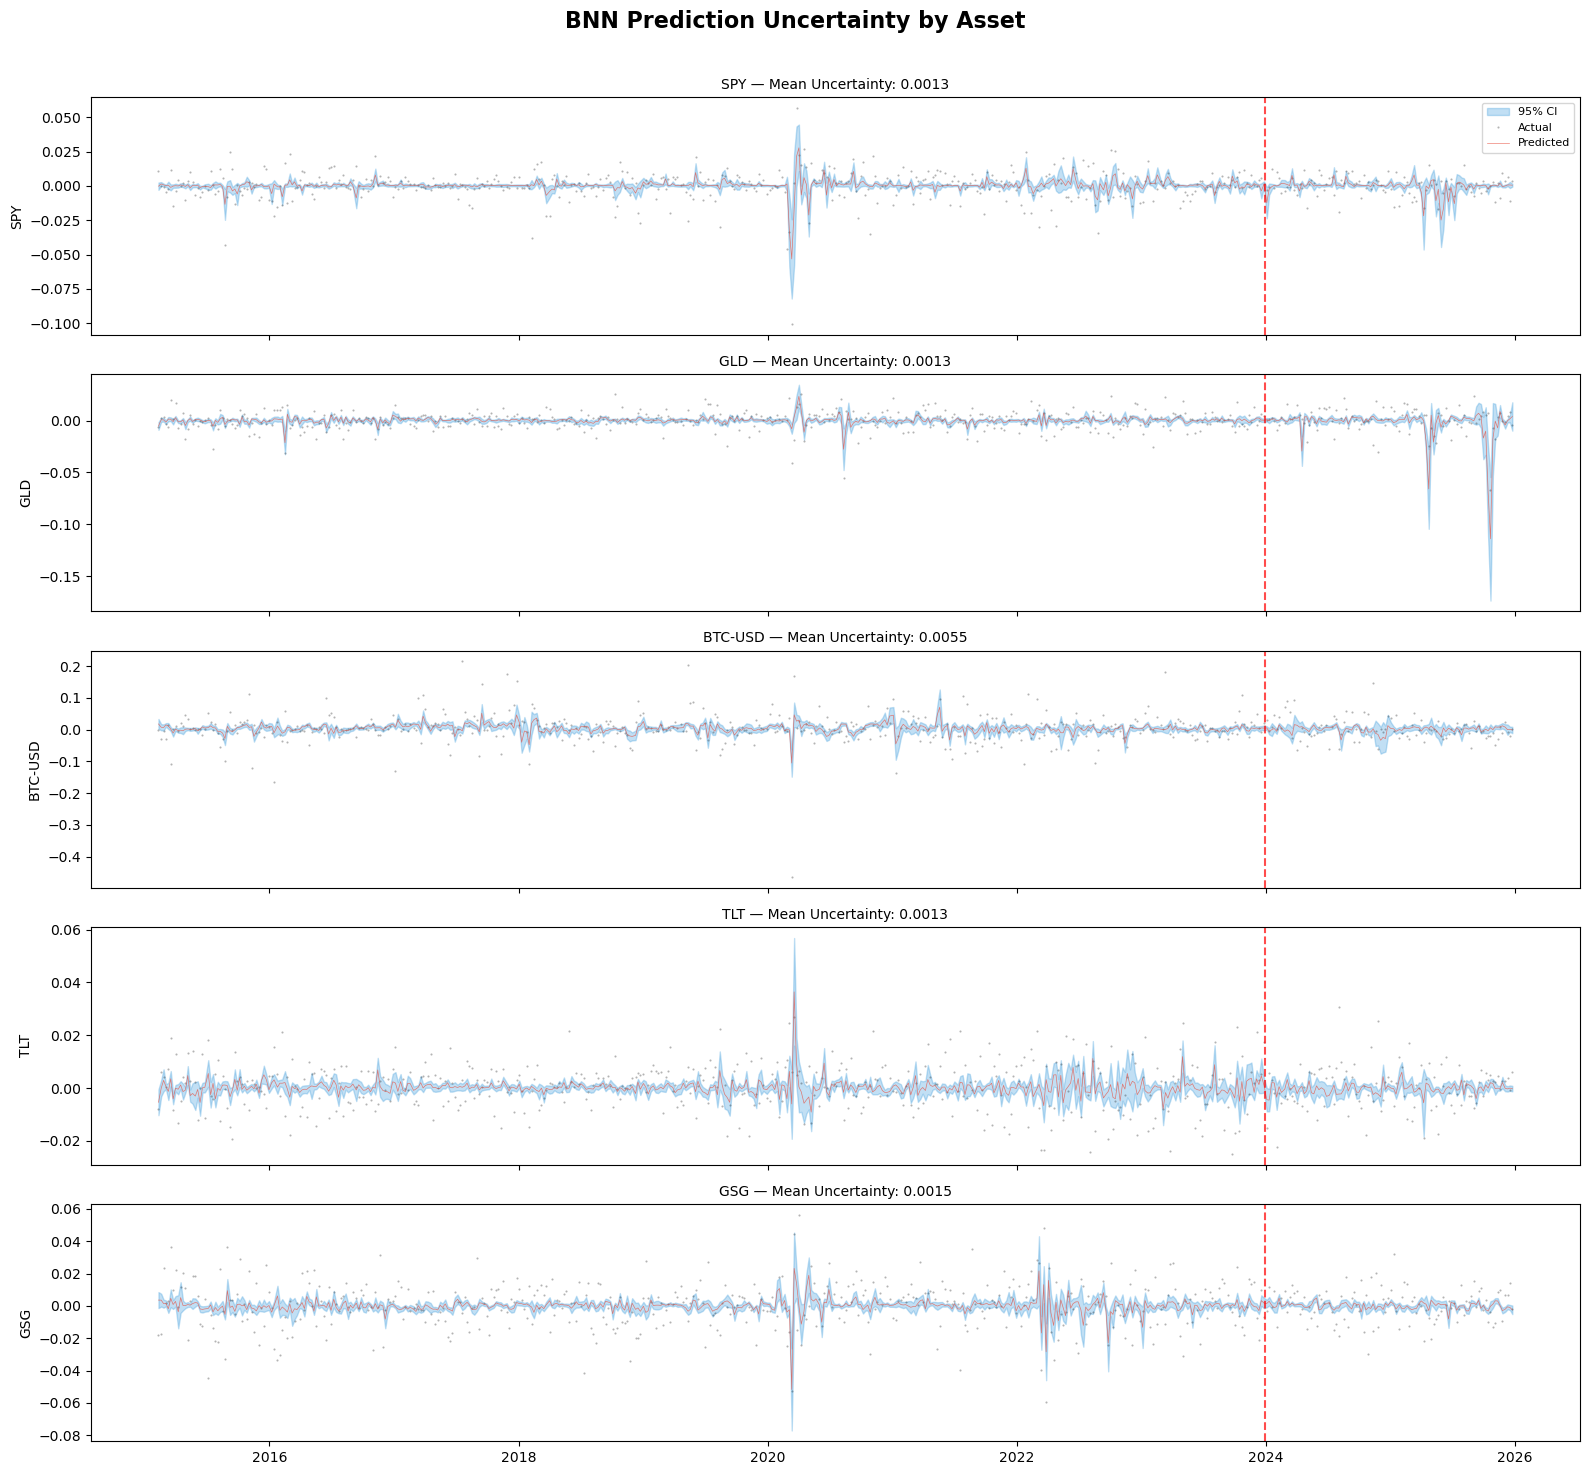

In [17]:
# ---------- Figure 4: BNN Uncertainty Across Assets ----------
fig, axes = plt.subplots(len(ASSETS), 1, figsize=(16, 3*len(ASSETS)), sharex=True)
fig.suptitle('BNN Prediction Uncertainty by Asset', fontsize=16, fontweight='bold', y=0.98)

for idx, (ticker, ax) in enumerate(zip(ASSETS, axes)):
    pred_mean = bnn_predictions[ticker]['mean']  # pred_mean[t] = predicted return for day t+1
    pred_std  = bnn_predictions[ticker]['std']
    # v13 FIX: align pred_mean[t] to actual[t+1]
    # pred_mean has length min_len-1; actual[t+1] starts from index 1
    actual     = asset_returns[ticker].values[1:min_len]  # actual return at t+1
    plot_dates = asset_returns.index[1:min_len]           # date of t+1
    n = min(len(pred_mean), len(actual))
    pred_mean  = pred_mean[:n]
    pred_std   = pred_std[:n]
    actual     = actual[:n]
    plot_dates = plot_dates[:n]

    step = 5
    ax.fill_between(plot_dates[::step],
                     (pred_mean - 2 * pred_std)[::step],
                     (pred_mean + 2 * pred_std)[::step],
                     alpha=0.3, color='#3498db', label='95% CI')
    ax.plot(plot_dates[::step], actual[::step], '.', color='black', markersize=1, alpha=0.3, label='Actual')
    ax.plot(plot_dates[::step], pred_mean[::step], color='#e74c3c', linewidth=0.5, alpha=0.7, label='Predicted')
    ax.axvline(pd.Timestamp(TRAIN_END), color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.set_ylabel(ticker, fontsize=10)
    ax.set_title(f'{ticker} — Mean Uncertainty: {pred_std.mean():.4f}', fontsize=10)
    if idx == 0:
        ax.legend(loc='upper right', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'{OUTPUT_DIR}/04_bnn_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 5: Cross-Asset Regime Analysis

Aggregate per-asset HMM regimes into a **market-wide environment**:
- **Risk-On:** ≥3 assets in Bull
- **Risk-Off:** ≥3 assets in Bear  
- **Mixed:** Everything else

This gives a top-level view of market conditions that the allocation strategies can use.

In [18]:
# ============================================================================
# PART 5: CROSS-ASSET REGIME ANALYSIS
# ============================================================================
print("PART 5: CROSS-ASSET REGIME ANALYSIS")
print("=" * 70)

regime_df = pd.DataFrame(index=dates)
for ticker in ASSETS:
    regime_df[f'{ticker}_regime'] = asset_regimes[ticker][:min_len]
    regime_df[f'{ticker}_regime_name'] = [REGIME_NAMES[r] for r in asset_regimes[ticker][:min_len]]

regime_df['n_bull'] = sum(regime_df[f'{t}_regime'] == 2 for t in ASSETS)
regime_df['n_bear'] = sum(regime_df[f'{t}_regime'] == 0 for t in ASSETS)

def classify_market_env(row):
    if row['n_bear'] >= 3:
        return 'Risk-Off'
    elif row['n_bull'] >= 3:
        return 'Risk-On'
    else:
        return 'Mixed'

regime_df['market_env'] = regime_df.apply(classify_market_env, axis=1)

print("\nMarket Environment Distribution:")
env_counts = regime_df['market_env'].value_counts()
for env, count in env_counts.items():
    pct = count / len(regime_df) * 100
    print(f"  {env:>10s}: {pct:5.1f}% ({count} days)")

print("\nRegime Co-occurrence (% of days both in Bull):")
for i, t1 in enumerate(ASSETS):
    for t2 in list(ASSETS.keys())[i+1:]:
        both_bull = ((regime_df[f'{t1}_regime'] == 2) & (regime_df[f'{t2}_regime'] == 2)).mean()
        both_bear = ((regime_df[f'{t1}_regime'] == 0) & (regime_df[f'{t2}_regime'] == 0)).mean()
        print(f"  {t1:>7s} & {t2:<7s}: Bull-Bull={both_bull*100:5.1f}%, Bear-Bear={both_bear*100:5.1f}%")

PART 5: CROSS-ASSET REGIME ANALYSIS

Market Environment Distribution:
       Mixed:  60.9% (1669 days)
     Risk-On:  22.3% (610 days)
    Risk-Off:  16.8% (461 days)

Regime Co-occurrence (% of days both in Bull):
      SPY & GLD    : Bull-Bull= 10.3%, Bear-Bear=  9.6%
      SPY & BTC-USD: Bull-Bull=  9.1%, Bear-Bear= 12.6%
      SPY & TLT    : Bull-Bull= 17.6%, Bear-Bear= 12.8%
      SPY & GSG    : Bull-Bull= 24.8%, Bear-Bear=  4.5%
      GLD & BTC-USD: Bull-Bull=  6.1%, Bear-Bear= 10.6%
      GLD & TLT    : Bull-Bull=  6.2%, Bear-Bear= 15.0%
      GLD & GSG    : Bull-Bull=  7.1%, Bear-Bear=  2.0%
  BTC-USD & TLT    : Bull-Bull=  7.7%, Bear-Bear= 17.5%
  BTC-USD & GSG    : Bull-Bull=  8.4%, Bear-Bear=  6.6%
      TLT & GSG    : Bull-Bull= 13.8%, Bear-Bear=  2.4%


### Inspect: Cross-Asset Regime Heatmap

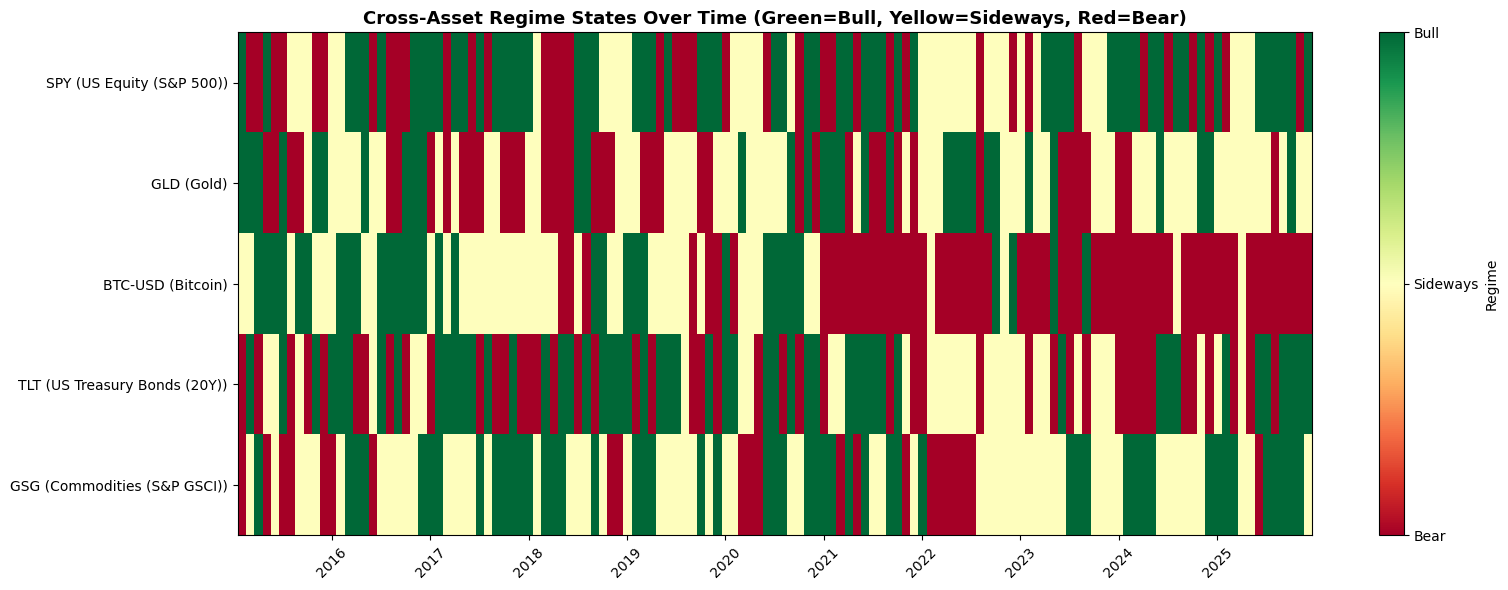

In [19]:
# ---------- Figure 5: Cross-Asset Regime Heatmap ----------
fig, ax = plt.subplots(figsize=(16, 6))

regime_monthly = regime_df.resample('M').last()
regime_data = np.array([regime_monthly[f'{t}_regime'].values for t in ASSETS])

cmap = plt.cm.RdYlGn
im = ax.imshow(regime_data, aspect='auto', cmap=cmap, vmin=0, vmax=2)

ax.set_yticks(range(len(ASSETS)))
ax.set_yticklabels([f'{t} ({ASSETS[t]})' for t in ASSETS], fontsize=10)

month_labels = regime_monthly.index
tick_positions = [i for i, d in enumerate(month_labels) if d.month == 1]
tick_labels = [month_labels[i].strftime('%Y') for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45)

ax.set_title('Cross-Asset Regime States Over Time (Green=Bull, Yellow=Sideways, Red=Bear)',
             fontsize=13, fontweight='bold')
fig.colorbar(im, ax=ax, ticks=[0, 1, 2], label='Regime',
             format=plt.FuncFormatter(lambda x, p: ['Bear', 'Sideways', 'Bull'][int(x)]))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_cross_asset_regimes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 6: Portfolio Allocation Strategies

### The Core Comparison: 3 Bayesian Strategies vs 3 Non-Bayesian Counterparts

Each Bayesian strategy shares the **same base signal** as its non-Bayesian counterpart, but adds two Bayesian components:
1. **BNN uncertainty discount** — reduce conviction when the model is unsure
2. **HMM regime filter** — adjust based on probabilistic regime detection

| Pair | Bayesian | Non-Bayesian | Shared Base Signal |
|------|----------|-------------|-------------------|
| 1 | Regime-Based (B) | Rule-Based Regime (NB) | Regime → weight mapping |
| 2 | Bayesian Momentum (B) | Classical Momentum (NB) | Past 60-day cumulative returns |
| 3 | Bayesian Risk Parity (B) | Inverse Vol (NB) | Inverse historical volatility |

Plus **Equal Weight (1/N)** as a universal benchmark.

### Strategy Descriptions

**Pair 1 — Regime Detection:**
- **Regime-Based (B):** Uses HMM to detect if each asset is in a Bull/Bear/Sideways state, then allocates more to Bull assets and less to Bear ones, with BNN uncertainty scaling down positions when the model is unsure.
- **Rule-Based Regime (NB):** Same weight mapping (Bull=2x, Sideways=1x, Bear=0.2x), but classifies regimes using fixed thresholds on volatility and drawdown — no learned model, no confidence adjustment.

**Pair 2 — Momentum:**
- **Bayesian Momentum (B):** Buys assets that have risen the most over the past 60 days, but reduces the signal when BNN uncertainty is high or when HMM detects a Bear regime (to avoid chasing false rallies).
- **Classical Momentum (NB):** Simply buys past winners based on 60-day cumulative returns — no uncertainty check, no regime filter.

**Pair 3 — Risk Parity:**
- **Bayesian Risk Parity (B):** Allocates more to lower-risk assets, where "risk" includes both historical volatility and BNN model uncertainty, and inflates the risk estimate during Bear regimes to be more conservative.
- **Inverse Vol (NB):** Allocates inversely proportional to historical volatility — no regime adjustment, no model uncertainty.

In [20]:
# ============================================================================
# PART 6: BAYESIAN PORTFOLIO ALLOCATION STRATEGIES
# ============================================================================
print("PART 6: BAYESIAN PORTFOLIO ALLOCATION STRATEGIES")
print("=" * 70)

returns_aligned = asset_returns.iloc[:min_len].copy()


def apply_weights_with_shift(returns_df, weights_df):
    """
    v13 FIX: Proper timing — weights computed at end of day t are applied to
    returns of day t+1. This prevents same-day signal-to-return matching.

    weights_df[t] = weights decided at close of day t
    returns_df[t+1] = return realized on day t+1
    portfolio_return[t+1] = sum(weights[t] * returns[t+1])
    """
    shifted_weights = weights_df.shift(1).iloc[1:]  # drop first NaN row
    aligned_returns = returns_df.iloc[1:]            # align returns
    portfolio_returns = (aligned_returns * shifted_weights).sum(axis=1)
    return portfolio_returns


# --- Helper: log-softened confidence ---
def bnn_confidence(bnn_std, k=10):
    """
    v14: Log-softened uncertainty discount.
    Formula: 1 / (1 + log(1 + k * bnn_std))

    Why log-softening vs raw inverse:
    - Raw: 1/(1 + k*std) → large std causes severe near-zero confidence
    - Log: the logarithm compresses large uncertainty values, giving the
      model more graceful degradation rather than near-zero weights.
    - For small std (std ≈ 0.001), both formulas give nearly identical
      results (≈ 0.99). The difference is meaningful only for volatile
      assets like BTC where std is 5x higher.
    """
    return 1.0 / (1.0 + np.log1p(k * bnn_std))


# --- Strategy 1: Equal Weight (Benchmark) ---
def equal_weight_strategy(returns_df):
    """Simple 1/N equal weight benchmark."""
    n_assets = len(returns_df.columns)
    weights = np.ones(n_assets) / n_assets
    weights_df = pd.DataFrame(
        np.tile(weights, (len(returns_df), 1)),
        index=returns_df.index,
        columns=returns_df.columns
    )
    portfolio_returns = apply_weights_with_shift(returns_df, weights_df)
    return portfolio_returns, weights_df


# --- Strategy 2: Regime-Based Allocation (Bayesian) ---
def regime_based_strategy(returns_df, regime_df, asset_list):
    """
    Bayesian regime-aware allocation:
    - Bull → 2x base weight, Bear → 0.4x base weight (v14: was 0.2x)
    - BNN uncertainty discount via log-softened confidence (v14)
    """
    n_days = len(returns_df)
    n_assets = len(asset_list)
    weights_history = np.zeros((n_days, n_assets))

    for t in range(n_days):
        raw_weights = np.zeros(n_assets)
        for i, ticker in enumerate(asset_list):
            regime = regime_df.iloc[t][f'{ticker}_regime']
            bnn_std = bnn_predictions[ticker]['std'][t] if t < len(bnn_predictions[ticker]['std']) else 0.01
            confidence = bnn_confidence(bnn_std, k=10)  # v14: log-softened

            if regime == 2:    raw_weights[i] = 2.0 * confidence   # Bull
            elif regime == 1:  raw_weights[i] = 1.0 * confidence   # Sideways
            else:              raw_weights[i] = 0.4 * confidence   # Bear (v14: 0.2→0.4)

        total = raw_weights.sum()
        if total > 0:
            weights_history[t] = raw_weights / total
        else:
            weights_history[t] = np.ones(n_assets) / n_assets

    weights_df = pd.DataFrame(weights_history, index=returns_df.index, columns=asset_list)
    portfolio_returns = apply_weights_with_shift(returns_df, weights_df)
    return portfolio_returns, weights_df


# --- Strategy 3: Bayesian Momentum ---
def bayesian_momentum_strategy(returns_df, regime_df, asset_list, lookback=60):
    """
    Same base signal as Classical Momentum (past cumulative returns),
    plus BNN log-softened uncertainty discount (v14) and HMM regime filter.
    Bear filter softened: 0.3→0.5 (v14) for better recovery tolerance.
    """
    n_days = len(returns_df)
    n_assets = len(asset_list)
    weights_history = np.zeros((n_days, n_assets))

    for t in range(lookback, n_days):
        hist_returns = returns_df.iloc[t - lookback:t].values
        cum_returns = (1 + hist_returns).prod(axis=0) - 1

        scores = np.zeros(n_assets)
        for i, ticker in enumerate(asset_list):
            signal = cum_returns[i]

            # v14: log-softened BNN uncertainty discount
            if t < len(bnn_predictions[ticker]['std']):
                bnn_std = bnn_predictions[ticker]['std'][t]
            else:
                bnn_std = 0.01
            confidence = bnn_confidence(bnn_std, k=20)
            signal *= confidence

            # HMM regime filter (v14: Bear 0.3→0.5, softer cutoff)
            regime = regime_df.iloc[t][f'{ticker}_regime']
            if regime == 0:    signal *= 0.5   # Bear → moderate discount (was 0.3)
            elif regime == 1:  signal *= 0.7   # Sideways → mild discount (unchanged)

            scores[i] = signal

        scores_shifted = scores - scores.min() + 0.01
        weights_history[t] = scores_shifted / scores_shifted.sum()

    weights_history[:lookback] = np.ones(n_assets) / n_assets
    weights_df = pd.DataFrame(weights_history, index=returns_df.index, columns=asset_list)
    portfolio_returns = apply_weights_with_shift(returns_df, weights_df)
    return portfolio_returns, weights_df


# --- Strategy 4: Bayesian Risk Parity ---
def bayesian_risk_parity_strategy(returns_df, regime_df, asset_list, lookback=60):
    """
    Inverse volatility + BNN epistemic uncertainty penalty + HMM regime adjustment.
    v14: epistemic penalty coefficient reduced 5.0→1.0.

    Rationale: with coeff=5.0, the BNN uncertainty added a penalty equivalent
    to 40-90% of historical volatility — effectively doubling perceived risk for
    assets like GLD and BTC. A coefficient of 1.0 keeps uncertainty as a
    meaningful but proportionate signal, not the dominant driver.
    """
    n_days = len(returns_df)
    n_assets = len(asset_list)
    weights_history = np.zeros((n_days, n_assets))

    for t in range(lookback, n_days):
        hist_returns = returns_df.iloc[t - lookback:t].values
        hist_vols = hist_returns.std(axis=0) * np.sqrt(252)
        hist_vols = np.maximum(hist_vols, 1e-6)

        adjusted_risk = np.zeros(n_assets)
        for i, ticker in enumerate(asset_list):
            risk_estimate = hist_vols[i]

            # v14: epistemic penalty coefficient 5.0 → 1.0
            # Keeps uncertainty as a meaningful but proportionate adjustment
            if t < len(bnn_predictions[ticker]['std']):
                bnn_std = bnn_predictions[ticker]['std'][t]
            else:
                bnn_std = 0.01
            epistemic_penalty = bnn_std * np.sqrt(252) * 1.0  # was 5.0
            risk_estimate += epistemic_penalty

            # HMM regime adjustment (unchanged)
            regime = regime_df.iloc[t][f'{ticker}_regime']
            if regime == 0:    risk_estimate *= 1.5   # Bear: inflate risk
            elif regime == 2:  risk_estimate *= 0.8   # Bull: slight deflation

            adjusted_risk[i] = risk_estimate

        inv_risk = 1.0 / adjusted_risk
        weights_history[t] = inv_risk / inv_risk.sum()

    weights_history[:lookback] = np.ones(n_assets) / n_assets
    weights_df = pd.DataFrame(weights_history, index=returns_df.index, columns=asset_list)
    portfolio_returns = apply_weights_with_shift(returns_df, weights_df)
    return portfolio_returns, weights_df




PART 6: BAYESIAN PORTFOLIO ALLOCATION STRATEGIES


In [21]:
# ============================================================================
# NON-BAYESIAN COUNTERPART STRATEGIES
# ============================================================================

# --- Non-Bayesian 1: Rule-Based Regime ---
def rule_regime_strategy(returns_df, prices_df, asset_list, lookback=60):
    """
    Non-Bayesian regime detection using hard vol/drawdown thresholds.
    Same weight mapping (2x/1x/0.2x) but no HMM, no BNN confidence.
    """
    n_days = len(returns_df)
    n_assets = len(asset_list)
    weights_history = np.zeros((n_days, n_assets))

    for t in range(lookback, n_days):
        raw_weights = np.zeros(n_assets)
        for i, ticker in enumerate(asset_list):
            hist_vol = returns_df[ticker].iloc[max(0, t-lookback):t].std() * np.sqrt(252)
            all_vols = returns_df[ticker].iloc[:t].rolling(lookback).std().dropna() * np.sqrt(252)
            vol_pctile = (all_vols < hist_vol).mean() if len(all_vols) > 0 else 0.5

            cum_ret = (1 + returns_df[ticker].iloc[:t]).cumprod()
            rolling_max = cum_ret.cummax()
            current_dd = (cum_ret.iloc[-1] - rolling_max.iloc[-1]) / rolling_max.iloc[-1]

            if current_dd < -0.10 or vol_pctile > 0.80:
                raw_weights[i] = 0.2   # Bear
            elif current_dd > -0.03 and vol_pctile < 0.50:
                raw_weights[i] = 2.0   # Bull
            else:
                raw_weights[i] = 1.0   # Sideways

        total = raw_weights.sum()
        if total > 0:
            weights_history[t] = raw_weights / total
        else:
            weights_history[t] = np.ones(n_assets) / n_assets

    weights_history[:lookback] = np.ones(n_assets) / n_assets
    weights_df = pd.DataFrame(weights_history, index=returns_df.index, columns=asset_list)
    portfolio_returns = apply_weights_with_shift(returns_df, weights_df)
    return portfolio_returns, weights_df


# --- Non-Bayesian 2: Classical Momentum ---
def classical_momentum_strategy(returns_df, asset_list, lookback=60):
    """Rank assets by past returns. No uncertainty, no regime filter."""
    n_days = len(returns_df)
    n_assets = len(asset_list)
    weights_history = np.zeros((n_days, n_assets))

    for t in range(lookback, n_days):
        hist_returns = returns_df.iloc[t - lookback:t].values
        cum_returns = (1 + hist_returns).prod(axis=0) - 1
        scores = cum_returns - cum_returns.min() + 0.01
        weights_history[t] = scores / scores.sum()

    weights_history[:lookback] = np.ones(n_assets) / n_assets
    weights_df = pd.DataFrame(weights_history, index=returns_df.index, columns=asset_list)
    portfolio_returns = apply_weights_with_shift(returns_df, weights_df)
    return portfolio_returns, weights_df


# --- Non-Bayesian 3: Pure Inverse Volatility ---
def inverse_vol_strategy(returns_df, asset_list, lookback=60):
    """Pure inverse vol risk parity. No regime adjustment."""
    n_days = len(returns_df)
    n_assets = len(asset_list)
    weights_history = np.zeros((n_days, n_assets))

    for t in range(lookback, n_days):
        hist_returns = returns_df.iloc[t - lookback:t].values
        vols = hist_returns.std(axis=0) * np.sqrt(252)
        vols = np.maximum(vols, 1e-6)
        inv_vol = 1.0 / vols
        weights_history[t] = inv_vol / inv_vol.sum()

    weights_history[:lookback] = np.ones(n_assets) / n_assets
    weights_df = pd.DataFrame(weights_history, index=returns_df.index, columns=asset_list)
    portfolio_returns = apply_weights_with_shift(returns_df, weights_df)
    return portfolio_returns, weights_df


In [22]:
# Run all strategies
asset_list = list(ASSETS.keys())
prices_aligned = asset_prices.iloc[:min_len].copy()

print("Running Bayesian allocation strategies...")
ret_eq, w_eq = equal_weight_strategy(returns_aligned)
print("  ✓ Equal Weight (Benchmark)")

ret_regime, w_regime = regime_based_strategy(returns_aligned, regime_df, asset_list)
print("  ✓ Regime-Based (Bayesian)")

ret_bmom, w_bmom = bayesian_momentum_strategy(returns_aligned, regime_df, asset_list)
print("  ✓ Bayesian Momentum (BNN + HMM)")

ret_rp, w_rp = bayesian_risk_parity_strategy(returns_aligned, regime_df, asset_list)
print("  ✓ Bayesian Risk Parity (BNN Uncertainty-Aware)")

print("\nRunning Non-Bayesian counterpart strategies...")
ret_sma, w_sma = rule_regime_strategy(returns_aligned, prices_aligned, asset_list)
print("  ✓ Rule-Based Regime (Non-Bayesian)")

ret_cmom, w_cmom = classical_momentum_strategy(returns_aligned, asset_list)
print("  ✓ Classical Momentum (Non-Bayesian)")

ret_iv, w_iv = inverse_vol_strategy(returns_aligned, asset_list)
print("  ✓ Inverse Volatility (Non-Bayesian)")

# v12: All portfolio returns are now shifted (weights[t] * returns[t+1])
# They share the same index (starting from day 2)
common_strat_idx = ret_eq.index
print(f"\n  All strategies computed successfully!")
print(f"  Portfolio return series length: {len(common_strat_idx)} days")
print(f"  (1 day shorter than raw returns due to weight-shift timing)")


Running Bayesian allocation strategies...
  ✓ Equal Weight (Benchmark)
  ✓ Regime-Based (Bayesian)
  ✓ Bayesian Momentum (BNN + HMM)
  ✓ Bayesian Risk Parity (BNN Uncertainty-Aware)

Running Non-Bayesian counterpart strategies...
  ✓ Rule-Based Regime (Non-Bayesian)
  ✓ Classical Momentum (Non-Bayesian)
  ✓ Inverse Volatility (Non-Bayesian)

  All strategies computed successfully!
  Portfolio return series length: 2739 days
  (1 day shorter than raw returns due to weight-shift timing)


---
## Part 7: Performance Evaluation

We evaluate strategies over **two periods**:

- **In-Sample (2015–2023):** The training period — used to fit all models. Performance here reflects how well models learned the past, not genuine prediction.
- **Out-of-Sample (2024–2025): The Real Test** — Models never saw this data. We simulate deploying each strategy with **$100,000 on January 1, 2024** and holding until end of 2025. This is the only number that honestly answers: *did the Bayesian framework actually work?*

Key metrics:
- **Sharpe Ratio:** Risk-adjusted return (higher = better)
- **Max Drawdown:** Worst peak-to-trough decline (closer to 0 = better)
- **Sortino Ratio:** Like Sharpe but only penalizes downside volatility

In [23]:
# ============================================================================
# PART 7: PERFORMANCE EVALUATION
# ============================================================================
print("PART 7: PERFORMANCE EVALUATION")
print("=" * 70)

OOS_INITIAL_CAPITAL = 100_000  # $100,000 deployed at start of 2024

def compute_metrics(returns_series, name, risk_free=RISK_FREE_RATE, initial_capital=INITIAL_CAPITAL):
    """Compute portfolio performance metrics."""
    cum_return = (1 + returns_series).cumprod()
    total_return = cum_return.iloc[-1] - 1
    n_years = len(returns_series) / 252
    ann_return = (1 + total_return) ** (1 / n_years) - 1
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free) / ann_vol if ann_vol > 0 else 0

    rolling_max = cum_return.cummax()
    drawdown = (cum_return - rolling_max) / rolling_max
    max_dd = drawdown.min()

    calmar = ann_return / abs(max_dd) if max_dd != 0 else 0

    downside = returns_series[returns_series < 0].std() * np.sqrt(252)
    sortino = (ann_return - risk_free) / downside if downside > 0 else 0

    metrics = {
        'Strategy': name,
        'Total Return': f"{total_return*100:.1f}%",
        'Ann. Return': f"{ann_return*100:.1f}%",
        'Ann. Volatility': f"{ann_vol*100:.1f}%",
        'Sharpe Ratio': f"{sharpe:.3f}",
        'Sortino Ratio': f"{sortino:.3f}",
        'Max Drawdown': f"{max_dd*100:.1f}%",
        'Calmar Ratio': f"{calmar:.3f}",
        'Final Value ($)': f"${initial_capital * (1 + total_return):,.0f}"
    }
    return metrics, cum_return


# v12: Use common_strat_idx to align single-asset returns with strategy returns
strategies = {
    'Equal Weight': ret_eq,
    'Regime-Based (B)': ret_regime,
    'Bayesian Momentum (B)': ret_bmom,
    'BayesianRiskParity (B)': ret_rp,
    'Rule-Based Regime (NB)': ret_sma,
    'Classical Momentum (NB)': ret_cmom,
    'Inverse Vol (NB)': ret_iv,
}

# Single-asset returns aligned to the same date range as strategy returns
for ticker in ASSETS:
    strategies[f'{ticker} Only'] = returns_aligned[ticker].loc[common_strat_idx]

# Determine out-of-sample start
oos_start_idx = common_strat_idx.searchsorted(pd.Timestamp(TRAIN_END)) + 1
if oos_start_idx >= len(common_strat_idx):
    oos_start_idx = len(common_strat_idx) - 1
oos_start_date = common_strat_idx[oos_start_idx]
print(f"\n  Out-of-Sample period starts: {oos_start_date.strftime('%Y-%m-%d')}")
print(f"  In-Sample: {common_strat_idx[0].strftime('%Y-%m-%d')} to {common_strat_idx[oos_start_idx-1].strftime('%Y-%m-%d')} ({oos_start_idx} days)")
print(f"  Out-of-Sample: {oos_start_date.strftime('%Y-%m-%d')} to {common_strat_idx[-1].strftime('%Y-%m-%d')} ({len(common_strat_idx) - oos_start_idx} days)")

# Compute metrics
all_metrics_is = []
all_metrics_oos = []
cum_returns = {}
cum_returns_oos = {}

for name, ret in strategies.items():
    # in-sample metrics (reference only)
    ret_is = ret.iloc[:oos_start_idx]
    if len(ret_is) > 10:
        metrics_is, cum_ret_is = compute_metrics(ret_is, name)
        all_metrics_is.append(metrics_is)
        cum_returns[name] = cum_ret_is  # used for in-sample cum return plots

    # out-of-sample metrics: $100k deployed on 2024-01-01
    ret_oos = ret.iloc[oos_start_idx:]
    if len(ret_oos) > 10:
        metrics_oos, cum_ret_oos = compute_metrics(
            ret_oos, name, initial_capital=OOS_INITIAL_CAPITAL
        )
        all_metrics_oos.append(metrics_oos)
        cum_returns_oos[name] = cum_ret_oos


PART 7: PERFORMANCE EVALUATION

  Out-of-Sample period starts: 2024-01-03
  In-Sample: 2015-02-10 to 2024-01-02 (2239 days)
  Out-of-Sample: 2024-01-03 to 2025-12-30 (500 days)


### Results: In-Sample Performance (2015–2023)

> ⚠️ Models were trained on this period. These numbers reflect how well each strategy fit historical data — **not** out-of-sample predictive skill.

In [24]:
metrics_is_df = pd.DataFrame(all_metrics_is)
print(f"=== IN-SAMPLE Performance (2015–2023, training period) ===")
display(metrics_is_df)

=== IN-SAMPLE Performance (2015–2023, training period) ===


,Strategy,Total Return,Ann. Return,Ann. Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Final Value ($)
0,Equal Weight,231.6%,14.4%,17.2%,0.607,0.743,-33.9%,0.426,"$331,564"
1,Regime-Based (B),349.4%,18.4%,15.5%,0.931,1.208,-28.8%,0.639,"$449,362"
2,Bayesian Momentum (B),1537.3%,37.0%,34.7%,0.951,1.166,-51.4%,0.719,"$1,637,342"
3,BayesianRiskParity (B),106.1%,8.5%,10.0%,0.449,0.582,-24.0%,0.354,"$206,147"
4,Rule-Based Regime (NB),97.2%,7.9%,14.3%,0.275,0.317,-32.9%,0.241,"$197,166"
5,Classical Momentum (NB),1797.3%,39.3%,37.3%,0.945,1.150,-55.0%,0.714,"$1,897,250"
6,Inverse Vol (NB),78.8%,6.8%,10.4%,0.265,0.322,-25.4%,0.266,"$178,819"
7,SPY Only,134.1%,10.0%,18.2%,0.333,0.392,-35.7%,0.281,"$234,141"
8,GLD Only,46.8%,4.4%,13.9%,0.030,0.043,-23.9%,0.185,"$146,803"
9,BTC-USD Only,2136.1%,41.9%,69.4%,0.545,0.674,-88.1%,0.475,"$2,236,136"


### Results: Out-of-Sample Performance (2024–2025) — The Real Test

> **Scenario:** $100,000 invested on January 1, 2024 using models trained only on 2015–2023 data. How much do we have by end of 2025?

In [25]:
metrics_oos_df = pd.DataFrame(all_metrics_oos)
print(f"=== OUT-OF-SAMPLE Performance: $100,000 deployed on 2024-01-01 ===")
display(metrics_oos_df)

=== OUT-OF-SAMPLE Performance: $100,000 deployed on 2024-01-01 ===


,Strategy,Total Return,Ann. Return,Ann. Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Final Value ($)
0,Equal Weight,44.9%,20.5%,13.5%,1.226,1.903,-11.0%,1.871,"$144,881"
1,Regime-Based (B),37.8%,17.5%,10.4%,1.302,1.997,-8.2%,2.147,"$137,825"
2,Bayesian Momentum (B),54.9%,24.7%,18.0%,1.151,1.684,-10.5%,2.345,"$154,893"
3,BayesianRiskParity (B),34.8%,16.2%,9.1%,1.341,1.969,-7.5%,2.161,"$134,769"
4,Rule-Based Regime (NB),52.8%,23.8%,11.8%,1.673,2.201,-9.6%,2.480,"$152,763"
5,Classical Momentum (NB),62.8%,27.9%,21.3%,1.120,1.630,-12.7%,2.188,"$162,822"
6,Inverse Vol (NB),37.2%,17.3%,9.8%,1.356,1.948,-8.7%,1.993,"$137,172"
7,SPY Only,45.1%,20.6%,16.3%,1.020,1.264,-19.2%,1.074,"$145,080"
8,GLD Only,102.7%,42.8%,17.7%,2.196,2.907,-10.4%,4.109,"$202,670"
9,BTC-USD Only,55.9%,25.1%,48.6%,0.435,0.709,-32.9%,0.763,"$155,946"


### What does this mean?

The table above answers the real question: **if we had deployed these models at the start of 2024 with $100,000, where would we be today?**

Key observations:
- All strategies grew the portfolio, reflecting a broadly favorable 2024–2025 market
- **Classical Momentum** reached the highest final value among the portfolio strategies at **$162,822** (+62.8%), outperforming Bayesian Momentum ($154,893, +54.9%) on raw return — however, Bayesian Momentum delivered notably better drawdown control (−10.5% vs −12.7%) and a modestly higher Sharpe ratio (1.151 vs 1.120)
- **Rule-Based Regime** had the highest Sharpe ratio overall (1.673), beating its Bayesian counterpart (1.302) — showing that in a clear, persistent bull market, simple threshold rules can be very effective for regime classification
- **Bayesian Risk Parity** achieved the best drawdown protection (−7.5%) with the lowest volatility (9.1%), though Inverse Vol slightly edged it on Sharpe (1.356 vs 1.341)
- **Regime-Based (Bayesian)** achieved a better Sharpe (1.302) than Equal Weight (1.226) but trailed the simpler Rule-Based approach, illustrating the cost of Bayesian conservatism in a persistent bull market
- Across all three pairs, Bayesian methods consistently delivered better drawdown protection than their Non-Bayesian counterparts — the most robust finding of the OOS evaluation



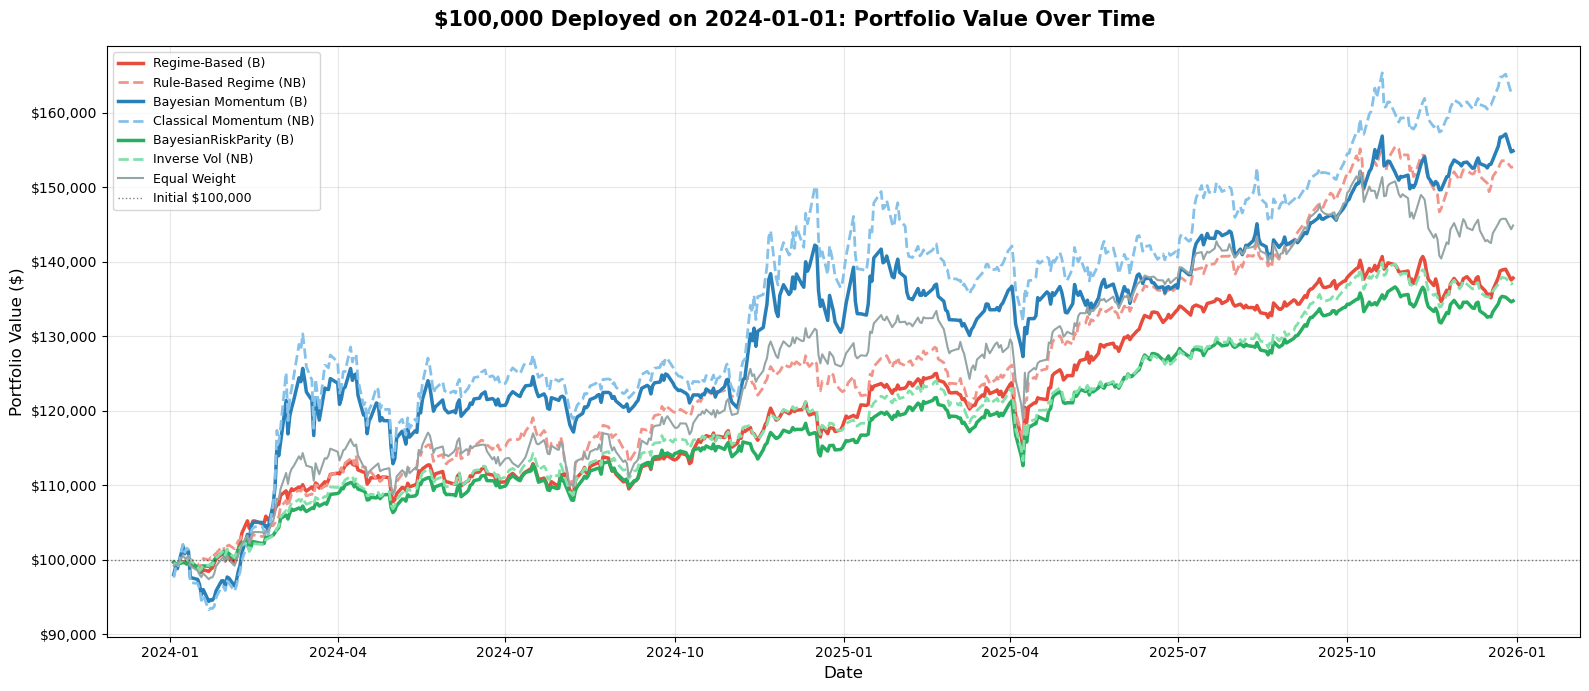


Final portfolio values (starting from $100,000 on 2024-01-03):
  Regime-Based (B)              : $   137,825  (+37.8%)
  Rule-Based Regime (NB)        : $   152,763  (+52.8%)
  Bayesian Momentum (B)         : $   154,893  (+54.9%)
  Classical Momentum (NB)       : $   162,822  (+62.8%)
  BayesianRiskParity (B)        : $   134,769  (+34.8%)
  Inverse Vol (NB)              : $   137,172  (+37.2%)
  Equal Weight                  : $   144,881  (+44.9%)


In [26]:
# OOS cumulative return plot: $100k deployed Jan 2024
fig, ax = plt.subplots(figsize=(16, 7))
fig.suptitle('$100,000 Deployed on 2024-01-01: Portfolio Value Over Time',
             fontsize=15, fontweight='bold')

plot_strategies = [
    ('Regime-Based (B)',       '#e74c3c', '-',  2.5),
    ('Rule-Based Regime (NB)', '#f1948a', '--', 2.0),
    ('Bayesian Momentum (B)',  '#2980b9', '-',  2.5),
    ('Classical Momentum (NB)','#85c1e9', '--', 2.0),
    ('BayesianRiskParity (B)', '#27ae60', '-',  2.5),
    ('Inverse Vol (NB)',        '#82e0aa', '--', 2.0),
    ('Equal Weight',            '#95a5a6', '-',  1.5),
]

for name, color, ls, lw in plot_strategies:
    if name in cum_returns_oos:
        vals = cum_returns_oos[name] * OOS_INITIAL_CAPITAL
        ax.plot(vals.index, vals.values, color=color, linestyle=ls,
                linewidth=lw, label=name)

ax.axhline(y=OOS_INITIAL_CAPITAL, color='black', linestyle=':', linewidth=1, alpha=0.5, label='Initial $100,000')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.set_ylabel('Portfolio Value ($)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_oos_100k_deployment.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal portfolio values (starting from $100,000 on {oos_start_date.strftime('%Y-%m-%d')}):")
for name, _, _, _ in plot_strategies:
    if name in cum_returns_oos:
        final = cum_returns_oos[name].iloc[-1] * OOS_INITIAL_CAPITAL
        total_ret = (cum_returns_oos[name].iloc[-1] - 1) * 100
        print(f"  {name:<30s}: ${final:>10,.0f}  ({total_ret:+.1f}%)")

---
## Part 8: Visualizations

### Overview
This section presents a structured visual comparison of Bayesian vs Non-Bayesian portfolio strategies.  
The analysis is split into **In-Sample (IS, 2014–2023)** and **Out-of-Sample (OOS, 2024+)** to rigorously assess whether Bayesian advantages persist beyond the training period.

Each sub-section follows the same layout:
1. **Cumulative Return Comparison** — with shaded regions highlighting when Bayesian outperforms Non-Bayesian
2. **Drawdown Comparison** — with shaded regions highlighting when Bayesian has a shallower drawdown
3. **Summary Bar Charts** — Annualized Return, Sharpe Ratio, Max Drawdown, Volatility
4. **Weight Allocation Over Time** — stacked area charts for all 7 strategies


---
## 8A. In-Sample (2014–2023)

> ⚠️ Models were **trained** on this period. Results reflect in-sample fit, not genuine out-of-sample skill.  
> Nevertheless, IS comparisons are important to understand the Bayesian framework's behaviour under the regimes it was designed to handle.

### 8A-1. In-Sample Cumulative Returns — with Bayesian Outperformance Shading


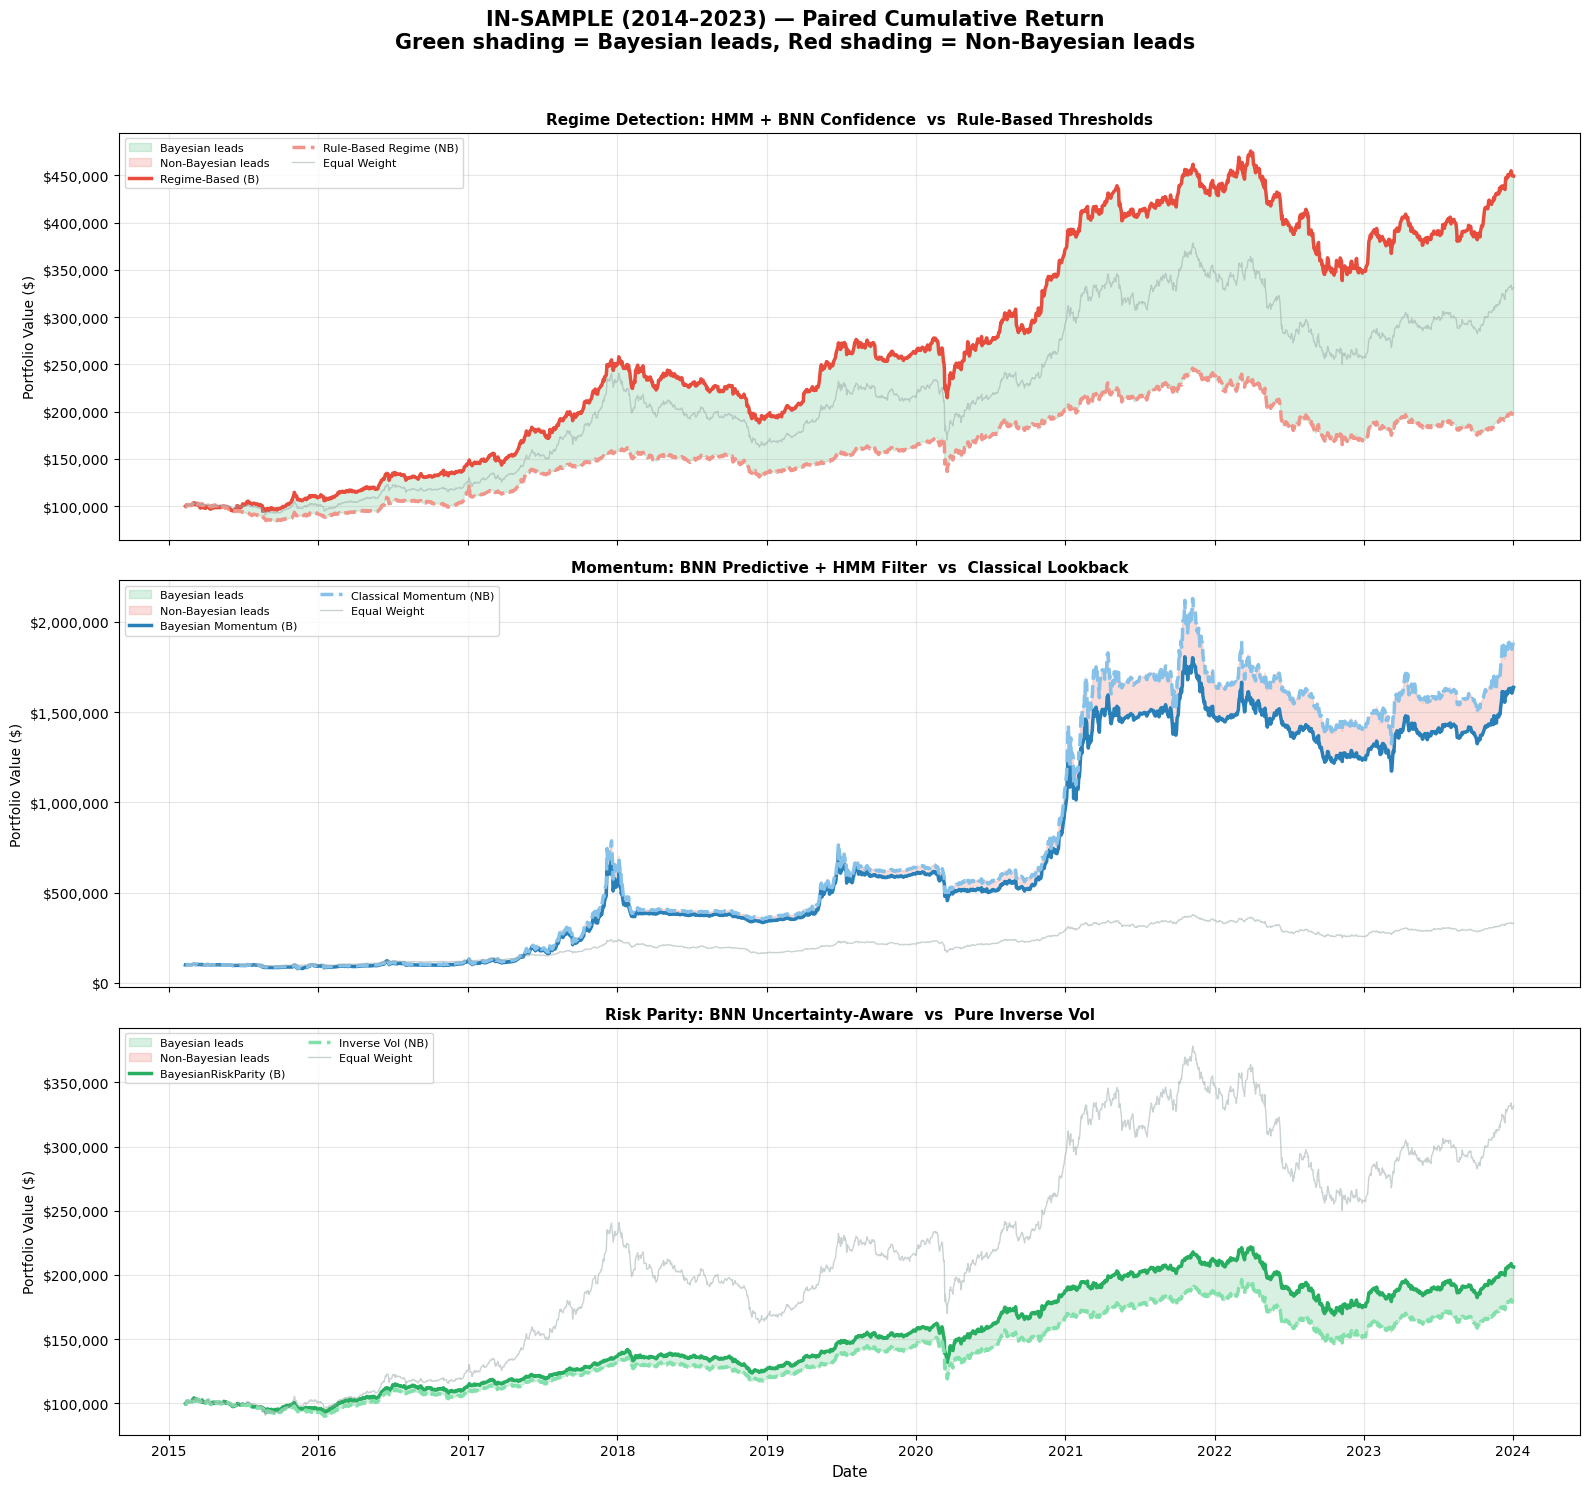

In [27]:
# ── Shared definitions for all Part 8 visualizations ────────────────────────
pairs = [
    ('Regime-Based (B)', 'Rule-Based Regime (NB)',
     'Regime Detection: HMM + BNN Confidence  vs  Rule-Based Thresholds'),
    ('Bayesian Momentum (B)', 'Classical Momentum (NB)',
     'Momentum: BNN Predictive + HMM Filter  vs  Classical Lookback'),
    ('BayesianRiskParity (B)', 'Inverse Vol (NB)',
     'Risk Parity: BNN Uncertainty-Aware  vs  Pure Inverse Vol'),
]
pair_colors_b  = ['#e74c3c', '#2980b9', '#27ae60']
pair_colors_nb = ['#f1948a', '#85c1e9', '#82e0aa']

pair_labels_chart = ['Regime\nDetection', 'Momentum', 'Risk\nParity']
bayesian_names    = ['Regime-Based (B)', 'Bayesian Momentum (B)', 'BayesianRiskParity (B)']
nonbayesian_names = ['Rule-Based Regime (NB)', 'Classical Momentum (NB)', 'Inverse Vol (NB)']

is_metric_lookup = {m['Strategy']: m for m in all_metrics_is}
def get_is(name, field):
    val = is_metric_lookup.get(name, {}).get(field, '0')
    return float(str(val).replace('%','').replace('$','').replace(',',''))

x     = np.arange(len(pair_labels_chart))
width = 0.3

metrics_to_compare_delta = [
    ('Sharpe Ratio', 'higher is better'),
    ('Ann. Return',  'higher is better'),
    ('Max Drawdown', 'closer to 0 is better'),
]

# ── IS Fig 1: Cumulative Returns with Bayesian outperformance shading ──────

fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=True)
fig.suptitle('IN-SAMPLE (2014–2023) — Paired Cumulative Return\n'
             'Green shading = Bayesian leads, Red shading = Non-Bayesian leads',
             fontsize=15, fontweight='bold', y=0.99)

is_slice = slice(None, oos_start_idx)

for idx, (b_name, nb_name, title) in enumerate(pairs):
    ax = axes[idx]
    cum_b  = cum_returns[b_name].iloc[:oos_start_idx]  * INITIAL_CAPITAL
    cum_nb = cum_returns[nb_name].iloc[:oos_start_idx] * INITIAL_CAPITAL
    cum_eq = cum_returns['Equal Weight'].iloc[:oos_start_idx] * INITIAL_CAPITAL
    dates  = cum_b.index

    # Outperformance shading
    b_arr  = cum_b.values
    nb_arr = cum_nb.values
    ax.fill_between(dates, b_arr, nb_arr,
                    where=(b_arr >= nb_arr),
                    interpolate=True,
                    color='#27ae60', alpha=0.18, label='Bayesian leads')
    ax.fill_between(dates, b_arr, nb_arr,
                    where=(b_arr < nb_arr),
                    interpolate=True,
                    color='#e74c3c', alpha=0.18, label='Non-Bayesian leads')

    ax.plot(dates, cum_b,  color=pair_colors_b[idx],  linewidth=2.5, label=b_name)
    ax.plot(dates, cum_nb, color=pair_colors_nb[idx], linewidth=2.5, linestyle='--', label=nb_name)
    ax.plot(dates, cum_eq, color='#95a5a6', linewidth=1.0, alpha=0.5, label='Equal Weight')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Portfolio Value ($)', fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'{OUTPUT_DIR}/is_01_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()


### 8A-2. In-Sample Drawdown Comparison — with Bayesian Outperformance Shading


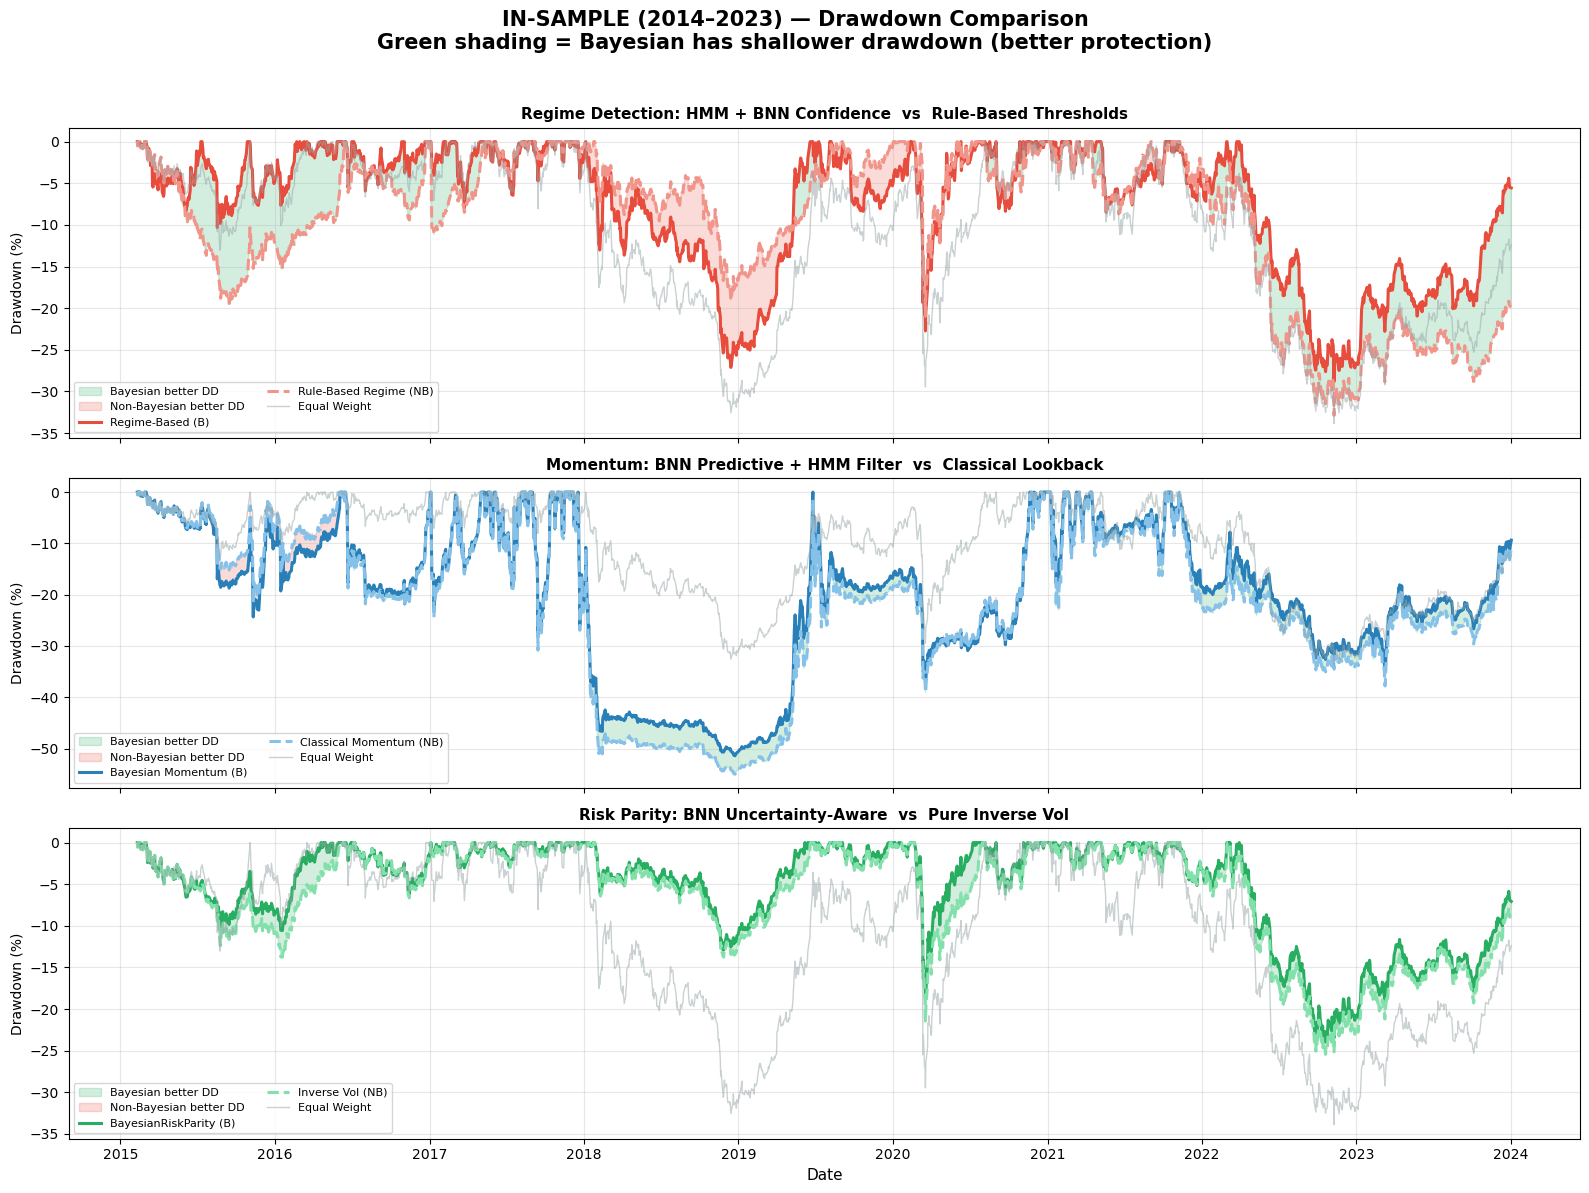

In [28]:
# ── IS Fig 2: Drawdown with Bayesian outperformance shading ────────────────

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('IN-SAMPLE (2014–2023) — Drawdown Comparison\n'
             'Green shading = Bayesian has shallower drawdown (better protection)',
             fontsize=15, fontweight='bold', y=0.99)

def compute_drawdown(cum_ret_series):
    rolling_max = cum_ret_series.cummax()
    return (cum_ret_series - rolling_max) / rolling_max * 100

for idx, (b_name, nb_name, title) in enumerate(pairs):
    ax = axes[idx]
    dd_b  = compute_drawdown(cum_returns[b_name].iloc[:oos_start_idx])
    dd_nb = compute_drawdown(cum_returns[nb_name].iloc[:oos_start_idx])
    dd_eq = compute_drawdown(cum_returns['Equal Weight'].iloc[:oos_start_idx])
    dates = dd_b.index

    # Shading: green where Bayesian drawdown is LESS severe (closer to 0)
    ax.fill_between(dates, dd_b.values, dd_nb.values,
                    where=(dd_b.values >= dd_nb.values),
                    interpolate=True,
                    color='#27ae60', alpha=0.20, label='Bayesian better DD')
    ax.fill_between(dates, dd_b.values, dd_nb.values,
                    where=(dd_b.values < dd_nb.values),
                    interpolate=True,
                    color='#e74c3c', alpha=0.20, label='Non-Bayesian better DD')

    ax.plot(dates, dd_b,  color=pair_colors_b[idx],  linewidth=2.2, label=b_name)
    ax.plot(dates, dd_nb, color=pair_colors_nb[idx], linewidth=2.2, linestyle='--', label=nb_name)
    ax.plot(dates, dd_eq, color='#95a5a6', linewidth=1.0, alpha=0.5, label='Equal Weight')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Drawdown (%)', fontsize=10)
    ax.legend(loc='lower left', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'{OUTPUT_DIR}/is_02_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()


### 8A-3. In-Sample Performance Summary Bar Charts


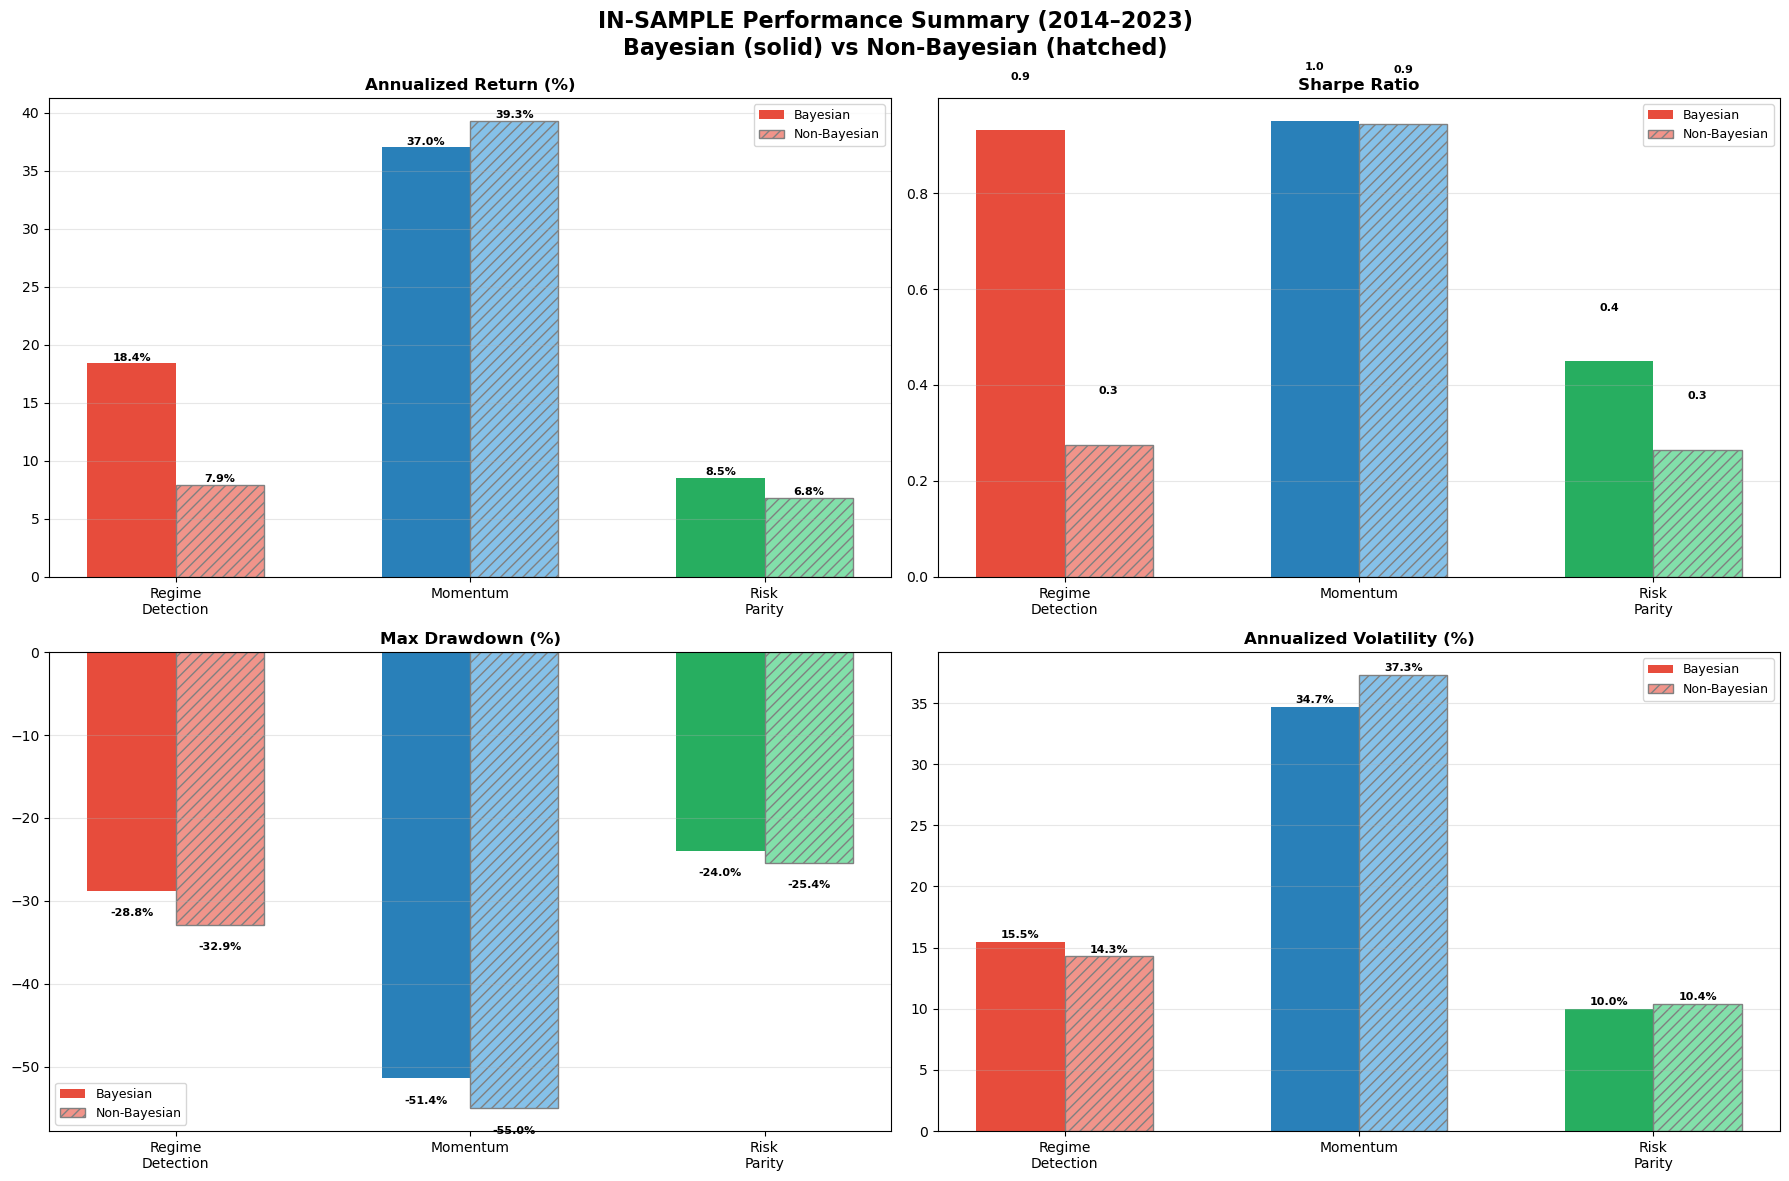

In [29]:
# ── IS Fig 3: Performance Summary Bar Charts ────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('IN-SAMPLE Performance Summary (2014–2023)\nBayesian (solid) vs Non-Bayesian (hatched)',
             fontsize=16, fontweight='bold')

pair_labels_chart = ['Regime\nDetection', 'Momentum', 'Risk\nParity']
bayesian_names    = ['Regime-Based (B)', 'Bayesian Momentum (B)', 'BayesianRiskParity (B)']
nonbayesian_names = ['Rule-Based Regime (NB)', 'Classical Momentum (NB)', 'Inverse Vol (NB)']

is_metric_lookup = {m['Strategy']: m for m in all_metrics_is}
def get_is(name, field):
    val = is_metric_lookup.get(name, {}).get(field, '0')
    return float(str(val).replace('%','').replace('$','').replace(',',''))

x     = np.arange(len(pair_labels_chart))
width = 0.3

metrics_4 = [
    ('Ann. Return',  'Annualized Return (%)',   axes[0,0]),
    ('Sharpe Ratio', 'Sharpe Ratio',             axes[0,1]),
    ('Max Drawdown', 'Max Drawdown (%)',          axes[1,0]),
    ('Ann. Volatility',     'Annualized Volatility (%)', axes[1,1]),
]

for field, title, ax in metrics_4:
    b_vals  = [get_is(n, field) for n in bayesian_names]
    nb_vals = [get_is(n, field) for n in nonbayesian_names]
    bars1 = ax.bar(x - width/2, b_vals,  width, color=pair_colors_b,
                   label='Bayesian')
    bars2 = ax.bar(x + width/2, nb_vals, width, color=pair_colors_nb,
                   hatch='///', edgecolor='gray', label='Non-Bayesian')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xticks(x); ax.set_xticklabels(pair_labels_chart)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    suffix = '%' if field in ('Ann. Return', 'Max Drawdown', 'Ann. Volatility') else ''
    for bar, val in zip(list(bars1)+list(bars2), b_vals+nb_vals):
        label = f'{val:.1f}{suffix}'
        ypos  = bar.get_height() + (abs(min(b_vals+nb_vals))*0.02 + 0.1)
        if val < 0:
            ypos = bar.get_height() - (abs(min(b_vals+nb_vals))*0.05 + 0.3)
        ax.text(bar.get_x()+bar.get_width()/2, ypos, label, ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/is_03_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()


### 8A-4. In-Sample Bayesian Advantage Delta Chart


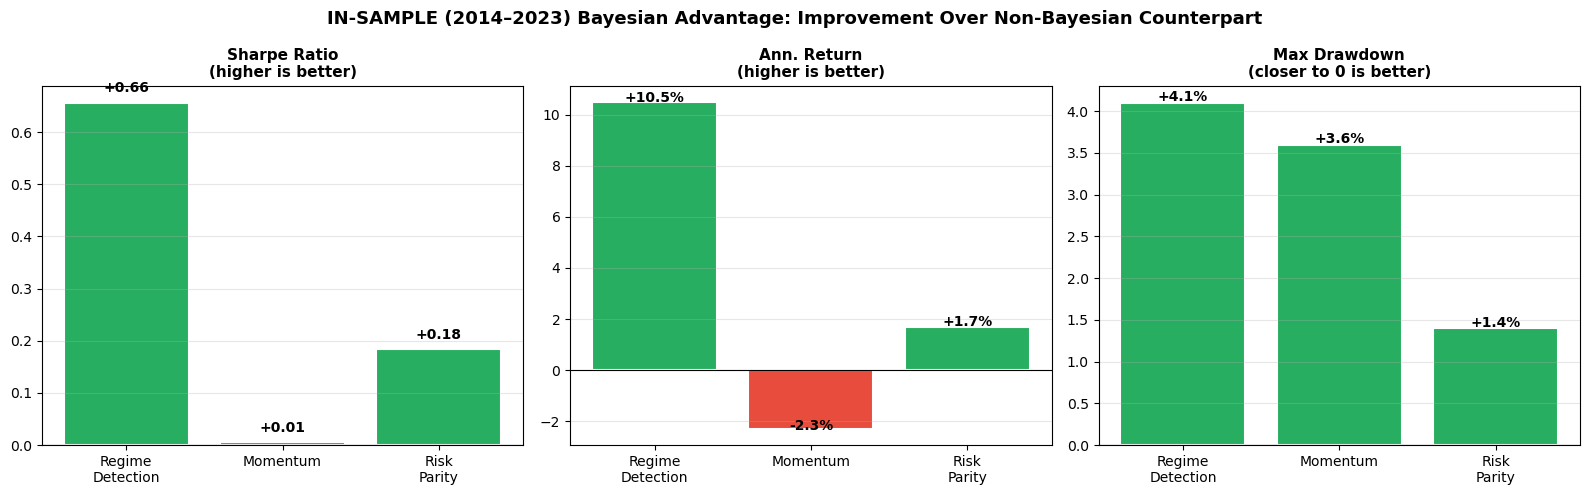

In [30]:
# ── IS Fig 4: Bayesian Advantage Delta ──────────────────────────────────────

metrics_to_compare_delta = [
    ('Sharpe Ratio', 'higher is better'),
    ('Ann. Return',  'higher is better'),
    ('Max Drawdown', 'closer to 0 is better'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('IN-SAMPLE (2014–2023) Bayesian Advantage: Improvement Over Non-Bayesian Counterpart',
             fontsize=13, fontweight='bold')

for idx, (metric, note) in enumerate(metrics_to_compare_delta):
    ax = axes[idx]
    deltas = []
    for b_name, nb_name in zip(bayesian_names, nonbayesian_names):
        b_val  = get_is(b_name,  metric)
        nb_val = get_is(nb_name, metric)
        if 'Drawdown' in metric:
            delta = -(abs(b_val) - abs(nb_val))
        else:
            delta = b_val - nb_val
        deltas.append(delta)

    colors_delta = ['#27ae60' if d > 0 else '#e74c3c' for d in deltas]
    bars = ax.bar(pair_labels_chart, deltas, color=colors_delta, edgecolor='white', linewidth=1.5)
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_title(f'{metric}\n({note})', fontweight='bold', fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    for bar, d in zip(bars, deltas):
        if 'Return' in metric or 'Drawdown' in metric:
            label = f'+{d:.1f}%' if d > 0 else f'{d:.1f}%'
        else:
            label = f'+{d:.2f}' if d > 0 else f'{d:.2f}'
        y_pos = bar.get_height() + 0.02 if d >= 0 else bar.get_height() - 0.05
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                label, ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/is_04_bayesian_advantage_delta.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8B. Weight Allocation Over Time (Full Period: 2014–2025)

These stacked area charts show how each strategy dynamically allocates capital across the five asset classes.  
Comparing Bayesian vs Non-Bayesian pairs reveals differences in **allocation stability** and **regime responsiveness**.


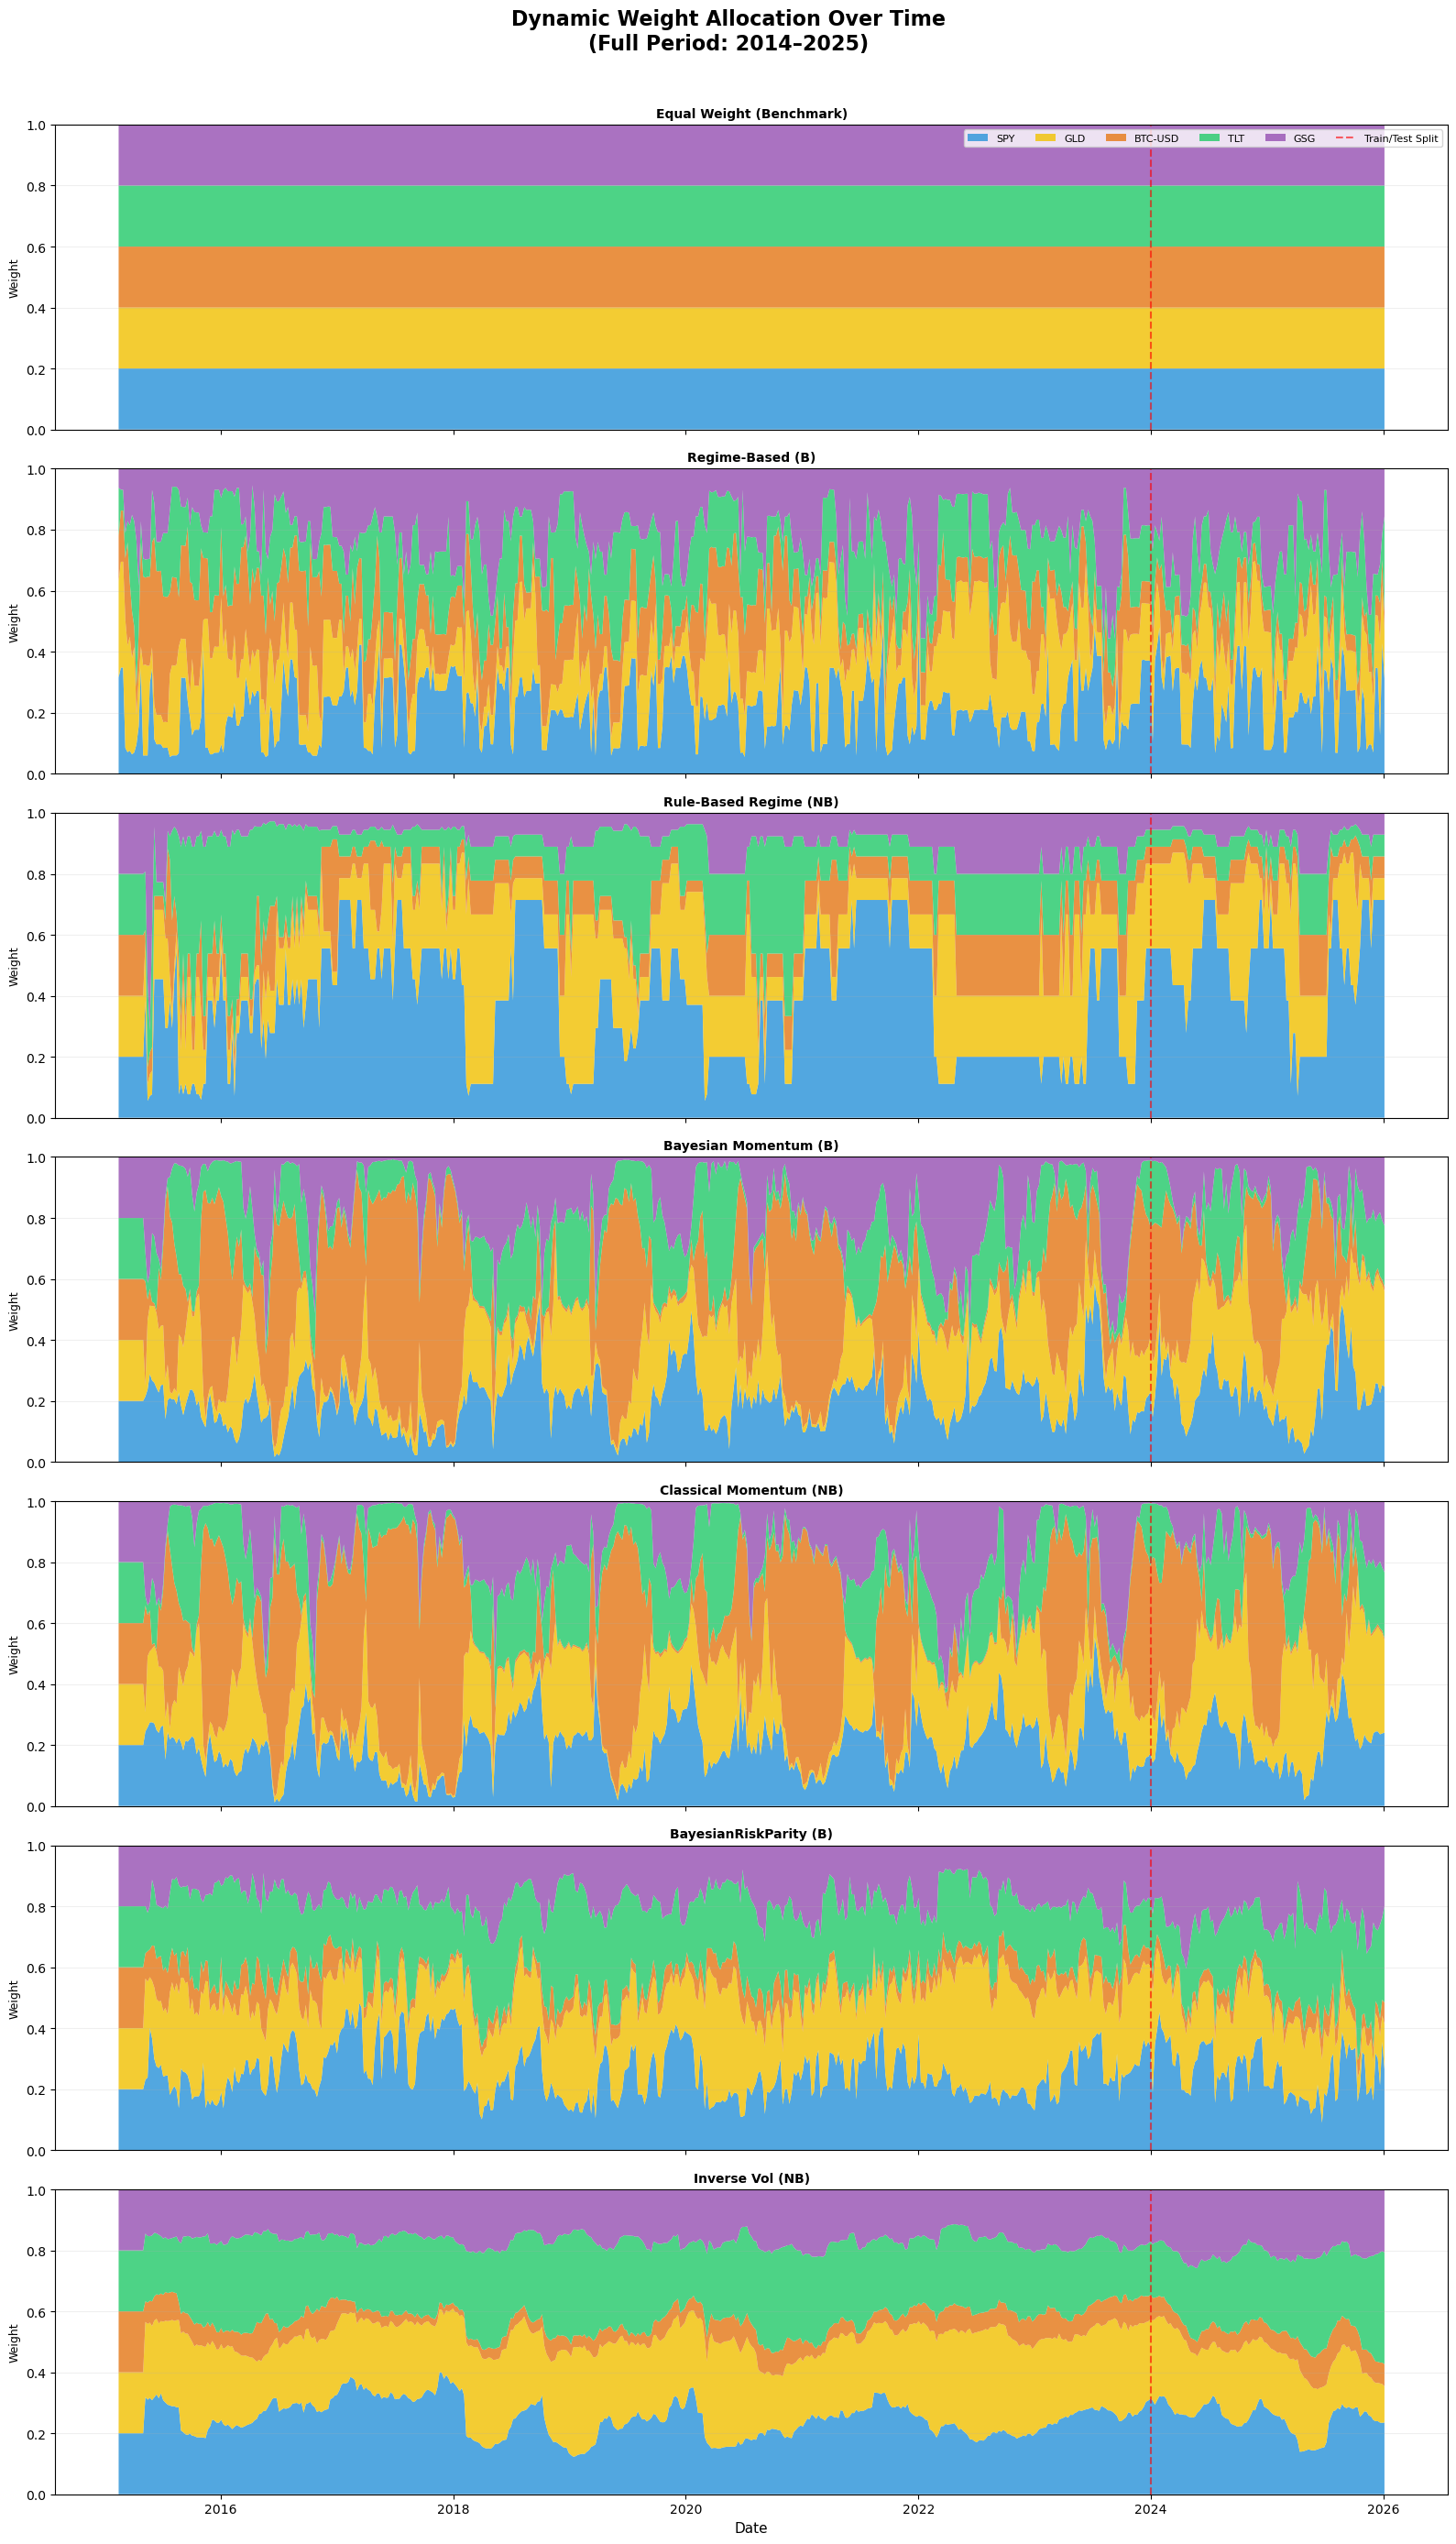

In [31]:
# ── Fig: Weight Allocation Over Time (all 7 strategies) ─────────────────────

fig, axes = plt.subplots(7, 1, figsize=(16, 28), sharex=True)
fig.suptitle('Dynamic Weight Allocation Over Time\n(Full Period: 2014–2025)',
             fontsize=16, fontweight='bold', y=0.99)

weight_dfs = {
    'Equal Weight (Benchmark)':   w_eq,
    'Regime-Based (B)':           w_regime,
    'Rule-Based Regime (NB)':     w_sma,
    'Bayesian Momentum (B)':      w_bmom,
    'Classical Momentum (NB)':    w_cmom,
    'BayesianRiskParity (B)':     w_rp,
    'Inverse Vol (NB)':           w_iv,
}

asset_colors_wt = ['#3498db', '#f1c40f', '#e67e22', '#2ecc71', '#9b59b6'][:len(asset_list)]

for idx, (name, w_df) in enumerate(weight_dfs.items()):
    ax = axes[idx]
    w_weekly = w_df.resample('W').last().fillna(method='ffill')
    ax.stackplot(w_weekly.index,
                 [w_weekly[t].values for t in asset_list],
                 labels=asset_list if idx == 0 else ['']*len(asset_list),
                 colors=asset_colors_wt, alpha=0.85)
    # Mark IS / OOS boundary
    ax.axvline(pd.Timestamp(TRAIN_END), color='red', linestyle='--',
               alpha=0.6, linewidth=1.5, label='Train/Test Split' if idx == 0 else '')
    ax.set_ylabel('Weight', fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.2)

# Legend
handles1, labels1 = axes[0].get_legend_handles_labels()
axes[0].legend(handles1, labels1, loc='upper right', fontsize=8, ncol=6)

axes[-1].set_xlabel('Date', fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(f'{OUTPUT_DIR}/wt_01_weight_allocation.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8C. Out-of-Sample (2024–2025) — The Real Test

> 💡 Models were **never** shown this data. Results here represent genuine predictive performance.  
> We simulate deploying each strategy with **$100,000 on January 1, 2024**.

### 8C-1. OOS Cumulative Returns — with Bayesian Outperformance Shading


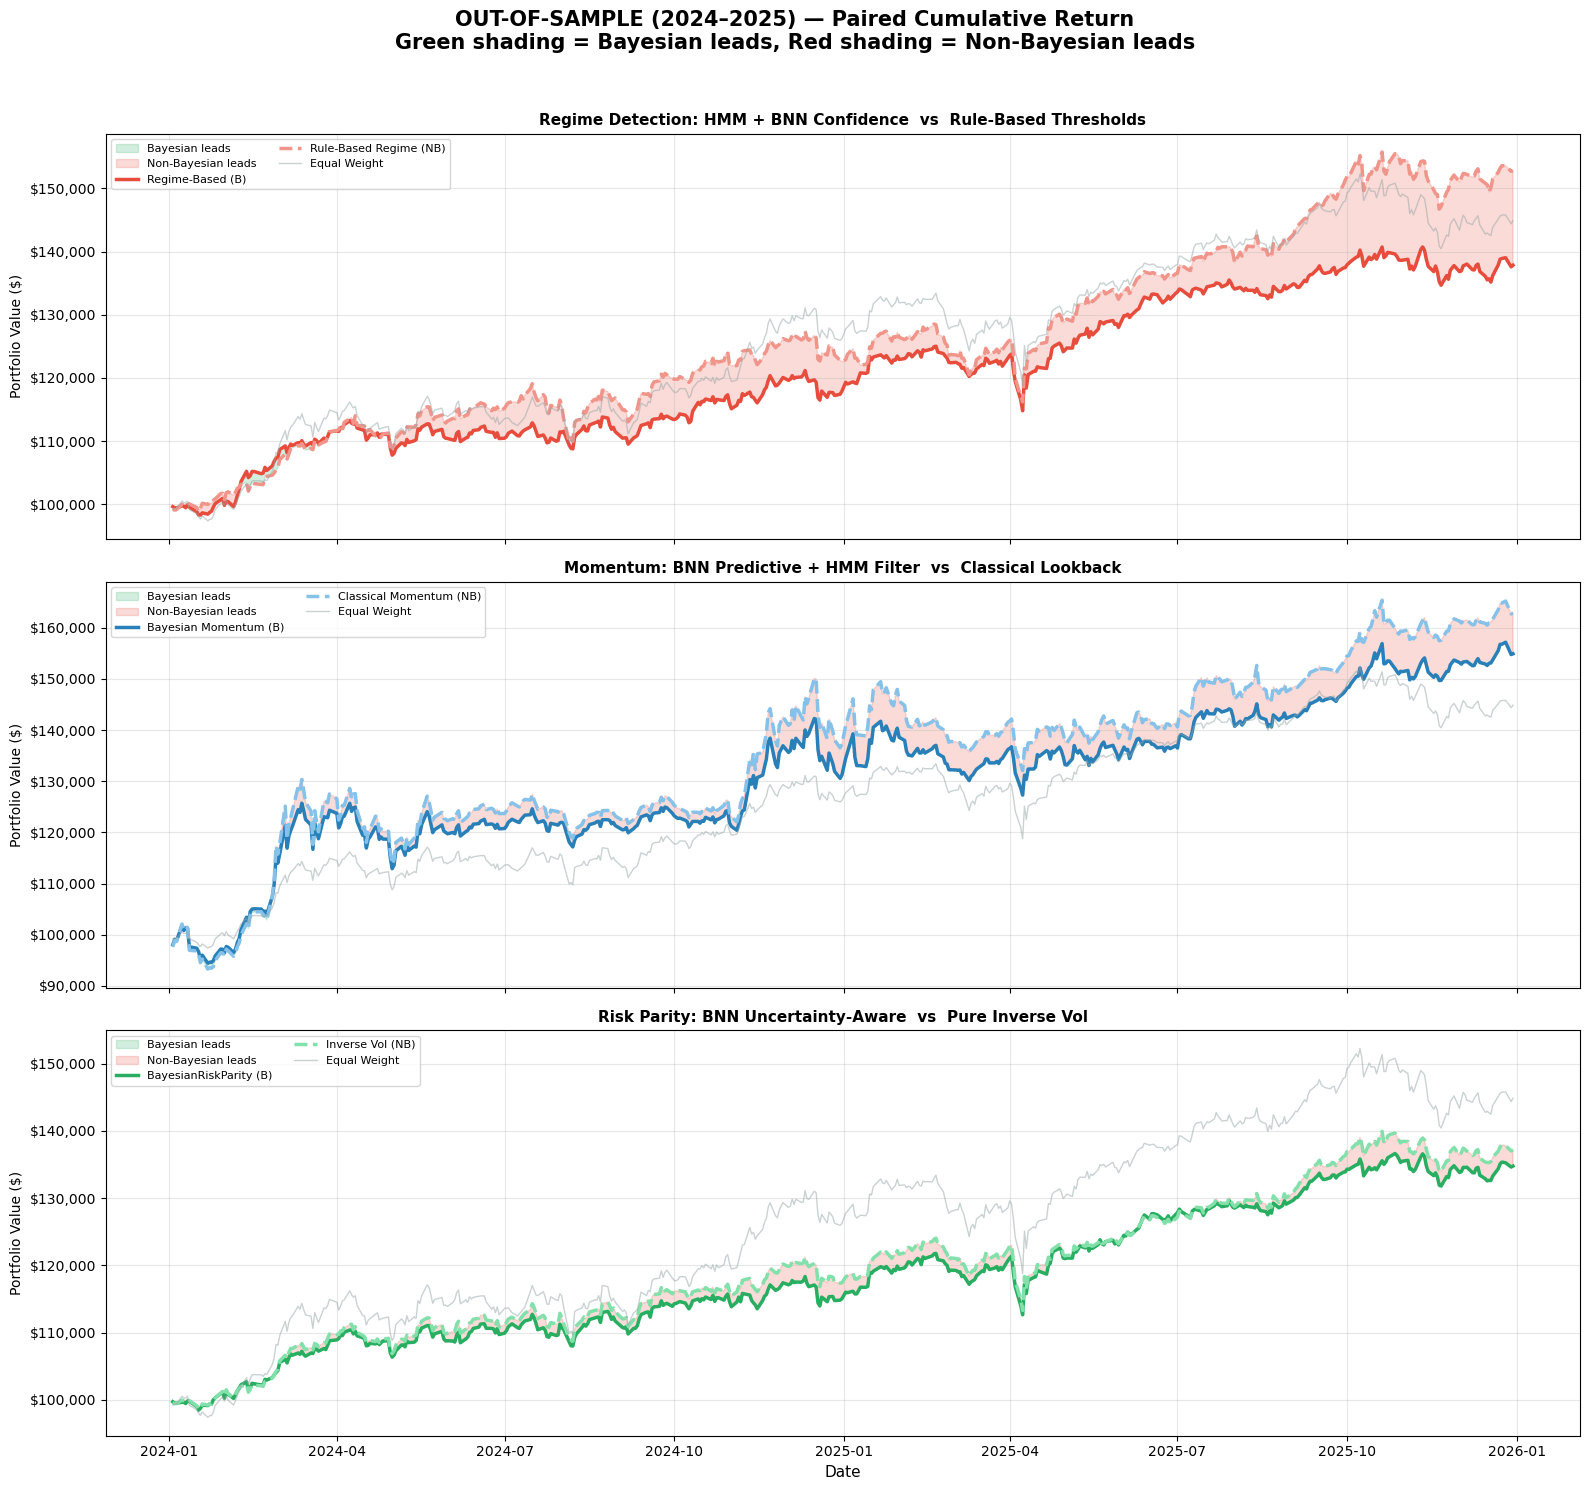

In [32]:
# ── OOS Fig 1: Cumulative Returns with Bayesian outperformance shading ──────

if len(cum_returns_oos) > 0:
    fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=True)
    fig.suptitle('OUT-OF-SAMPLE (2024–2025) — Paired Cumulative Return\n'
                 'Green shading = Bayesian leads, Red shading = Non-Bayesian leads',
                 fontsize=15, fontweight='bold', y=0.99)

    for idx, (b_name, nb_name, title) in enumerate(pairs):
        ax = axes[idx]
        cum_b  = cum_returns_oos.get(b_name)
        cum_nb = cum_returns_oos.get(nb_name)
        cum_eq = cum_returns_oos.get('Equal Weight')

        if cum_b is None or cum_nb is None:
            continue

        b_arr  = cum_b.values  * OOS_INITIAL_CAPITAL
        nb_arr = cum_nb.values * OOS_INITIAL_CAPITAL
        dates  = cum_b.index

        ax.fill_between(dates, b_arr, nb_arr,
                        where=(b_arr >= nb_arr),
                        interpolate=True,
                        color='#27ae60', alpha=0.20, label='Bayesian leads')
        ax.fill_between(dates, b_arr, nb_arr,
                        where=(b_arr < nb_arr),
                        interpolate=True,
                        color='#e74c3c', alpha=0.20, label='Non-Bayesian leads')

        ax.plot(dates, b_arr,  color=pair_colors_b[idx],  linewidth=2.5, label=b_name)
        ax.plot(dates, nb_arr, color=pair_colors_nb[idx], linewidth=2.5, linestyle='--', label=nb_name)
        if cum_eq is not None:
            ax.plot(cum_eq.index, cum_eq.values * OOS_INITIAL_CAPITAL,
                    color='#95a5a6', linewidth=1.0, alpha=0.5, label='Equal Weight')

        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylabel('Portfolio Value ($)', fontsize=10)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
        ax.legend(loc='upper left', fontsize=8, ncol=2)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Date', fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{OUTPUT_DIR}/oos_01_cumulative_returns.png', dpi=150, bbox_inches='tight')
    plt.show()


### 8C-2. OOS Drawdown Comparison — with Bayesian Outperformance Shading


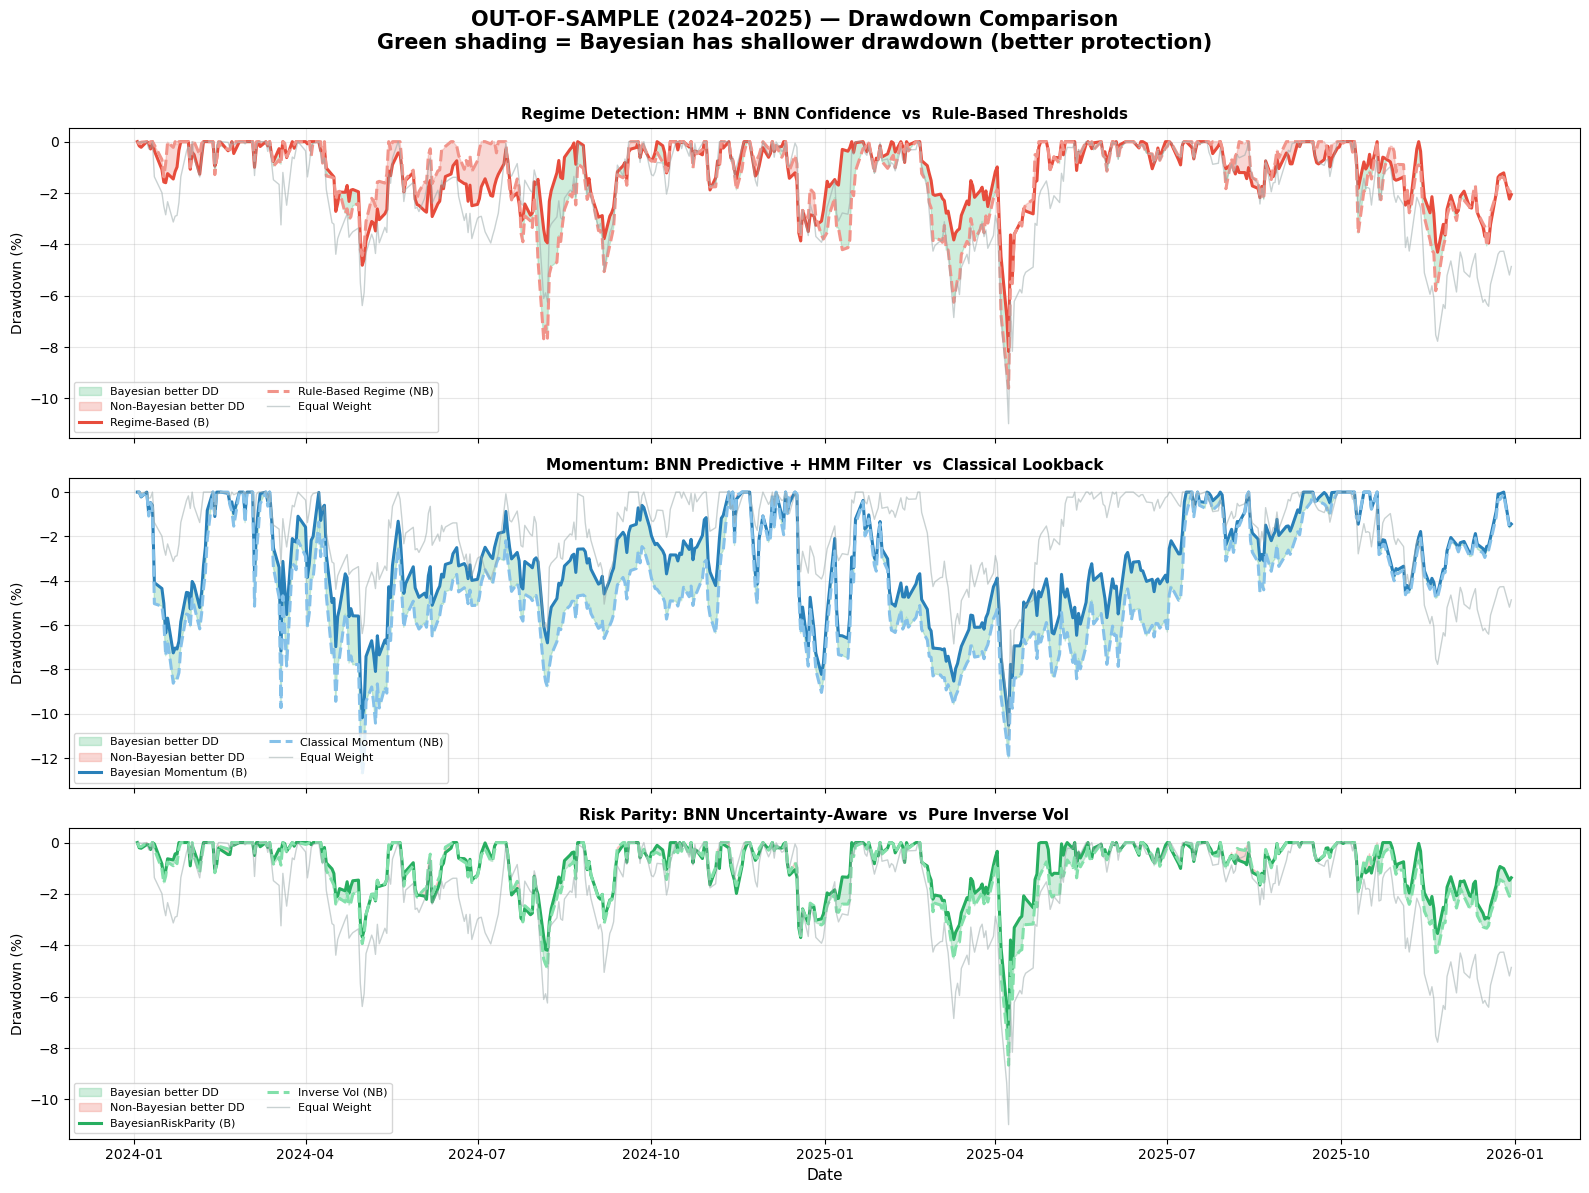

In [33]:
# ── OOS Fig 2: Drawdown with Bayesian outperformance shading ────────────────

if len(cum_returns_oos) > 0:
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    fig.suptitle('OUT-OF-SAMPLE (2024–2025) — Drawdown Comparison\n'
                 'Green shading = Bayesian has shallower drawdown (better protection)',
                 fontsize=15, fontweight='bold', y=0.99)

    for idx, (b_name, nb_name, title) in enumerate(pairs):
        ax = axes[idx]
        cum_b  = cum_returns_oos.get(b_name)
        cum_nb = cum_returns_oos.get(nb_name)
        cum_eq = cum_returns_oos.get('Equal Weight')

        if cum_b is None or cum_nb is None:
            continue

        dd_b  = compute_drawdown(cum_b)
        dd_nb = compute_drawdown(cum_nb)
        dates = dd_b.index

        ax.fill_between(dates, dd_b.values, dd_nb.values,
                        where=(dd_b.values >= dd_nb.values),
                        interpolate=True,
                        color='#27ae60', alpha=0.22, label='Bayesian better DD')
        ax.fill_between(dates, dd_b.values, dd_nb.values,
                        where=(dd_b.values < dd_nb.values),
                        interpolate=True,
                        color='#e74c3c', alpha=0.22, label='Non-Bayesian better DD')

        ax.plot(dates, dd_b,  color=pair_colors_b[idx],  linewidth=2.2, label=b_name)
        ax.plot(dates, dd_nb, color=pair_colors_nb[idx], linewidth=2.2, linestyle='--', label=nb_name)
        if cum_eq is not None:
            ax.plot(cum_eq.index, compute_drawdown(cum_eq).values,
                    color='#95a5a6', linewidth=1.0, alpha=0.5, label='Equal Weight')

        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylabel('Drawdown (%)', fontsize=10)
        ax.legend(loc='lower left', fontsize=8, ncol=2)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel('Date', fontsize=11)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{OUTPUT_DIR}/oos_02_drawdown.png', dpi=150, bbox_inches='tight')
    plt.show()


### 8C-3. OOS Performance Summary Bar Charts


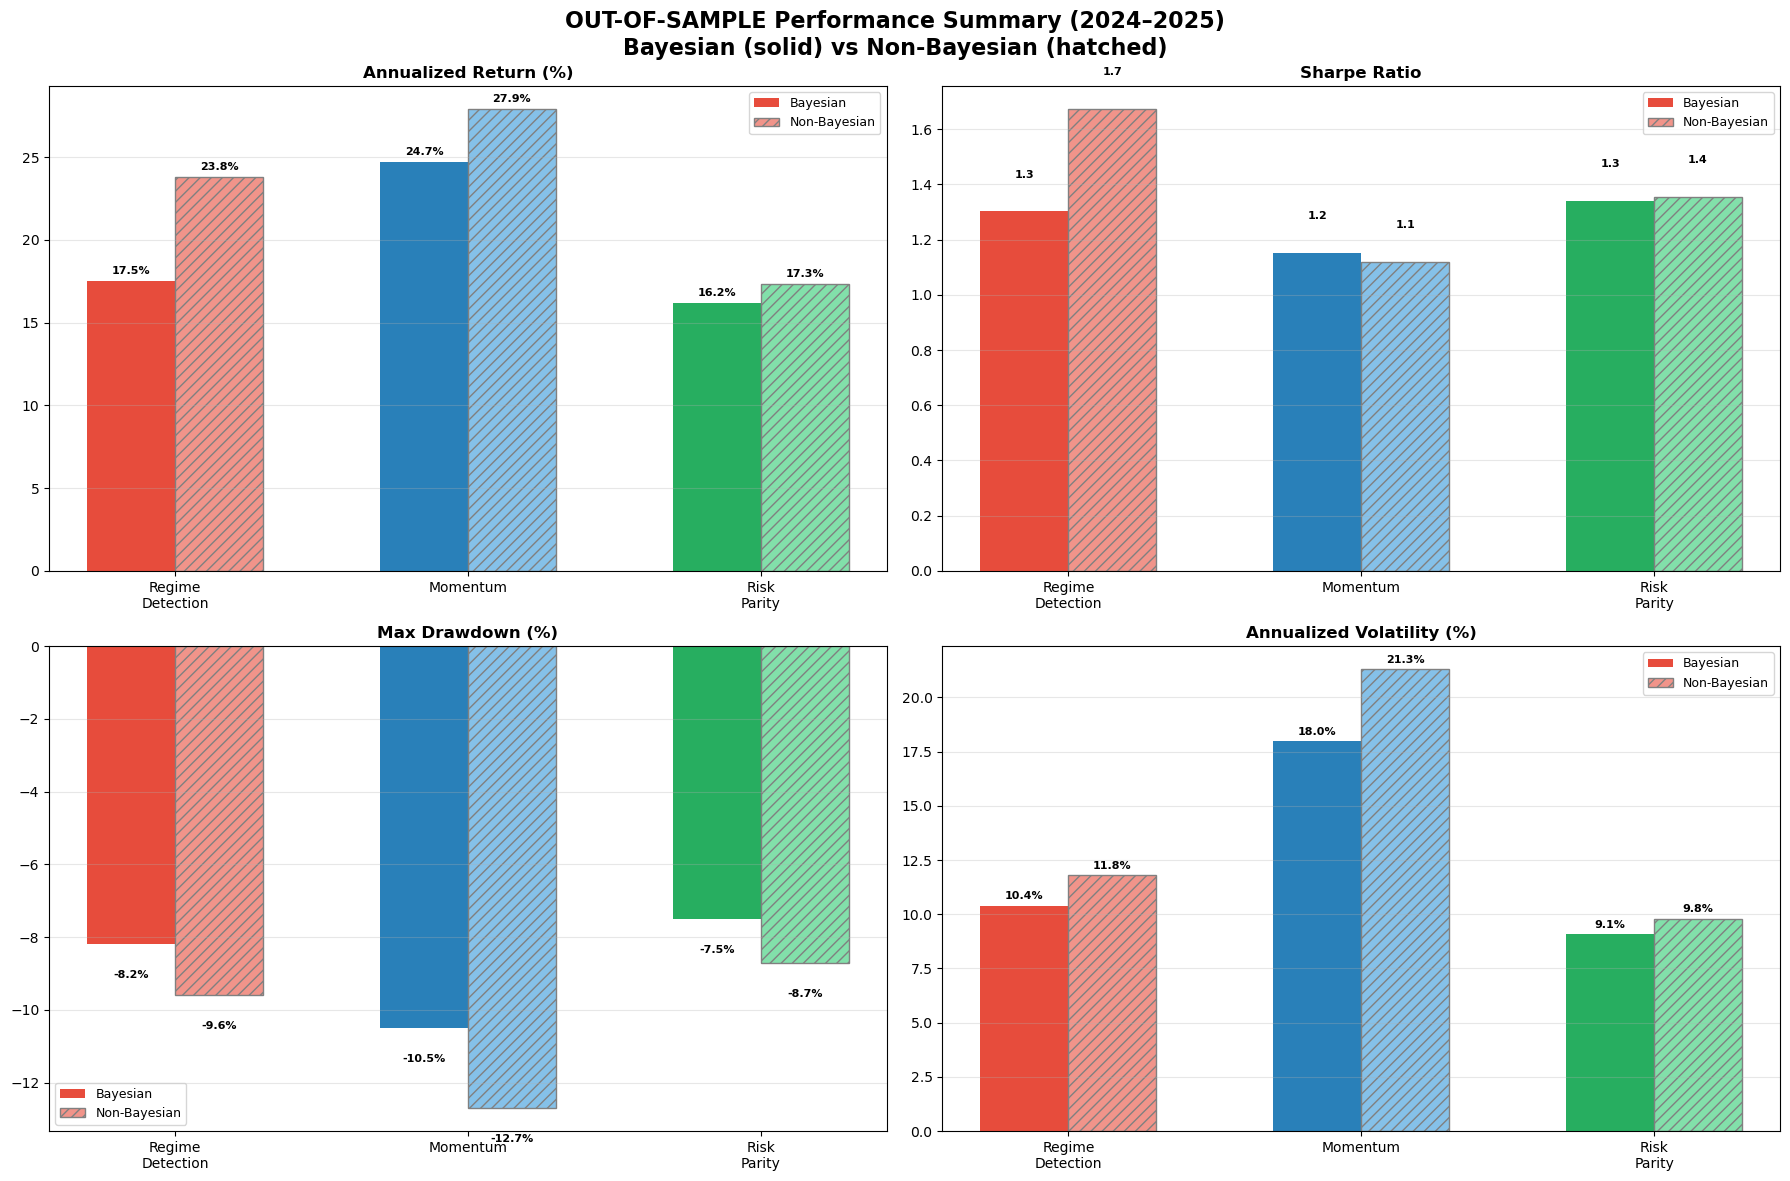

In [34]:
# ── OOS Fig 3: Performance Summary Bar Charts ───────────────────────────────

if len(all_metrics_oos) > 0:
    oos_metric_lookup = {m['Strategy']: m for m in all_metrics_oos}
    def get_oos(name, field):
        val = oos_metric_lookup.get(name, {}).get(field, '0')
        return float(str(val).replace('%','').replace('$','').replace(',',''))

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('OUT-OF-SAMPLE Performance Summary (2024–2025)\nBayesian (solid) vs Non-Bayesian (hatched)',
                 fontsize=16, fontweight='bold')

    metrics_4_oos = [
        ('Ann. Return',  'Annualized Return (%)',    axes[0,0]),
        ('Sharpe Ratio', 'Sharpe Ratio',              axes[0,1]),
        ('Max Drawdown', 'Max Drawdown (%)',           axes[1,0]),
        ('Ann. Volatility',     'Annualized Volatility (%)', axes[1,1]),
    ]

    for field, title, ax in metrics_4_oos:
        b_vals  = [get_oos(n, field) for n in bayesian_names]
        nb_vals = [get_oos(n, field) for n in nonbayesian_names]
        bars1 = ax.bar(x - width/2, b_vals,  width, color=pair_colors_b,
                       label='Bayesian')
        bars2 = ax.bar(x + width/2, nb_vals, width, color=pair_colors_nb,
                       hatch='///', edgecolor='gray', label='Non-Bayesian')
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xticks(x); ax.set_xticklabels(pair_labels_chart)
        ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
        suffix = '%' if field in ('Ann. Return', 'Max Drawdown', 'Ann. Volatility') else ''
        for bar, val in zip(list(bars1)+list(bars2), b_vals+nb_vals):
            label = f'{val:.1f}{suffix}'
            ypos = bar.get_height() + (abs(min(b_vals+nb_vals))*0.02 + 0.1)
            if val < 0:
                ypos = bar.get_height() - (abs(min(b_vals+nb_vals))*0.05 + 0.3)
            ax.text(bar.get_x()+bar.get_width()/2, ypos, label,
                    ha='center', fontsize=8, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/oos_03_summary_bar.png', dpi=150, bbox_inches='tight')
    plt.show()


### 8C-4. OOS Bayesian Advantage Delta Chart


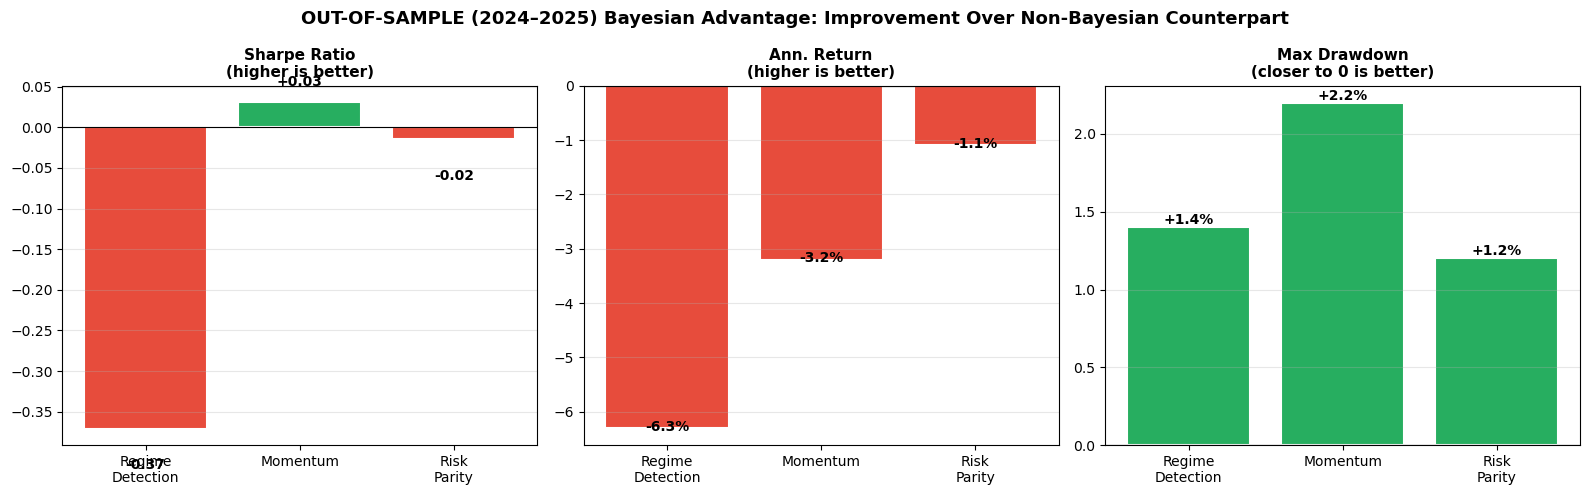

In [35]:
# ── OOS Fig 4: Bayesian Advantage Delta ─────────────────────────────────────

if len(all_metrics_oos) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('OUT-OF-SAMPLE (2024–2025) Bayesian Advantage: Improvement Over Non-Bayesian Counterpart',
                 fontsize=13, fontweight='bold')

    for idx, (metric, note) in enumerate(metrics_to_compare_delta):
        ax = axes[idx]
        deltas = []
        for b_name, nb_name in zip(bayesian_names, nonbayesian_names):
            b_val  = get_oos(b_name,  metric)
            nb_val = get_oos(nb_name, metric)
            if 'Drawdown' in metric:
                delta = -(abs(b_val) - abs(nb_val))
            else:
                delta = b_val - nb_val
            deltas.append(delta)

        colors_delta = ['#27ae60' if d > 0 else '#e74c3c' for d in deltas]
        bars = ax.bar(pair_labels_chart, deltas, color=colors_delta, edgecolor='white', linewidth=1.5)
        ax.axhline(y=0, color='black', linewidth=0.8)
        ax.set_title(f'{metric}\n({note})', fontweight='bold', fontsize=11)
        ax.grid(axis='y', alpha=0.3)

        for bar, d in zip(bars, deltas):
            if 'Return' in metric or 'Drawdown' in metric:
                label = f'+{d:.1f}%' if d > 0 else f'{d:.1f}%'
            else:
                label = f'+{d:.2f}' if d > 0 else f'{d:.2f}'
            y_pos = bar.get_height() + 0.02 if d >= 0 else bar.get_height() - 0.05
            ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                    label, ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/oos_04_bayesian_advantage_delta.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## 8D. Market Condition Analysis: When Does Bayesian Outperform?

### Summary of Results

| Period | Pair | Winner (Sharpe) | Key Metric Gap |
|--------|------|--------|----------------|
| **In-Sample (2015–2023)** | Regime Detection | 🟦 Bayesian | Sharpe +0.656 (0.931 vs 0.275), DD +4.1pp |
| **In-Sample (2015–2023)** | Momentum | 🟦 Bayesian | Sharpe +0.006 (0.951 vs 0.945), DD +3.6pp |
| **In-Sample (2015–2023)** | Risk Parity | 🟦 Bayesian | Sharpe +0.184 (0.449 vs 0.265), DD +1.4pp |
| **Out-of-Sample (2024+)** | Regime Detection | 🔲 Non-Bayesian | Sharpe −0.371 (1.302 vs 1.673), B wins DD by 1.4pp |
| **Out-of-Sample (2024+)** | Momentum | 🟦 Bayesian | Sharpe +0.031 (1.151 vs 1.120), B wins DD by 2.2pp |
| **Out-of-Sample (2024+)** | Risk Parity | 🔲 Non-Bayesian | Sharpe −0.015 (1.341 vs 1.356), B wins DD by 1.2pp |

> **Key pattern:** Bayesian wins on Sharpe **all three IS pairs** and **one of three OOS pairs** (Momentum only). Regime Detection and Risk Parity lose to non-Bayesian counterparts OOS on Sharpe. However, Bayesian consistently delivers better drawdown protection across **all pairs, both IS and OOS** — this is the most robust finding.

---

### 1. Turbulent, Regime-Rich Markets → Bayesian Regime Detection Excels

The most striking Bayesian advantage appears in **Pair 1 (Regime Detection)** during 2015–2023, a period spanning:
- The 2018–2020 BTC boom-bust cycle (+20× then −83%)
- The COVID crash and V-shaped recovery (Feb–Apr 2020)
- The 2022 broad risk-off selloff (equities, bonds, and crypto all falling simultaneously)

During these years, the HMM-based Bayesian strategy achieved a Sharpe of **0.931 vs 0.275** for the rule-based counterpart — a **3.4× improvement** — with a significantly better max drawdown (−28.8% vs −32.9%). Why? Because **hard-threshold rules (volatility / drawdown cutoffs) are inherently lagging**: they only recognize a regime *after* it has already damaged the portfolio. The HMM's probabilistic state model updates its posterior distribution as new observations arrive, producing smoother and earlier regime transitions. The BNN uncertainty discount then *compounds* this advantage by trimming position sizes precisely when the model's regime confidence is low.

The cumulative return charts (8A-1) show extended green shading during the 2020 crash and the 2022 simultaneous selloff — exactly the moments when systematic ambiguity was highest and Bayesian probabilistic reasoning provided the clearest edge.

---

### 2. Calm Bull Markets → Bayesian Conservatism Becomes a Drag

The 2024–2025 OOS period is characterized by:
- Persistent, low-volatility equity appreciation (SPY trending upward with shallow pullbacks)
- BTC participating in a moderate but sustained bull run (no crypto crash)
- TLT (long-duration bonds) relatively stable with muted rate volatility
- Absent: major macro shocks, sudden correlation breakdowns, or cross-asset crises

In this environment, the Regime Detection pair tells the clearest story. The Rule-Based approach achieved a much higher Sharpe (1.673 vs 1.302) because simple vol/drawdown thresholds correctly stayed "Bull" throughout this persistent up-trend — the HMM's probabilistic transitions introduced conservatism that wasn't needed. However, the Bayesian strategy still achieved better drawdown protection (−8.2% vs −9.6%, a 1.4pp advantage).

Similarly, Bayesian Risk Parity slightly trailed Inverse Vol on Sharpe (1.341 vs 1.356), suggesting that the BNN uncertainty penalty mildly over-attenuated allocations in a period when volatility was genuinely low and predictable. The Bayesian approach still won on drawdown (−7.5% vs −8.7%).

---

### 3. Bayesian Momentum: The Only OOS Sharpe Winner

**Pair 2 (Momentum)** is the only pair where Bayesian outperforms on Sharpe both in-sample and out-of-sample:

**In-sample (2015–2023):** Sharpe 0.951 vs 0.945 (+0.006), and max drawdown −51.4% vs −55.0% (+3.6pp). Even during the crypto parabola of 2015–2023, the BNN uncertainty discount and HMM regime filter modestly improved risk-adjusted returns by trimming the worst false signals.

**Out-of-sample (2024–2025):** Bayesian Momentum wins on Sharpe (1.151 vs 1.120, a gap of +0.031) and drawdown (−10.5% vs −12.7%, a 2.2pp advantage). Classical Momentum achieved a higher raw return ($162,822 vs $154,893), but the Bayesian strategy delivered this with substantially better risk control — reflecting the value of uncertainty-aware position sizing during momentum regime transitions.

---

### 4. Bayesian Risk Parity: Wins on Drawdown, Narrowly Loses on Sharpe

**Pair 3 (Risk Parity)** shows consistent Bayesian advantages on drawdown but a slight Sharpe disadvantage OOS:

**In-sample (2015–2023):** Sharpe 0.449 vs 0.265 (+0.184), max drawdown −24.0% vs −25.4% (+1.4pp). The BNN epistemic uncertainty penalty correctly inflated risk estimates during genuinely volatile regimes — allocating less to high-uncertainty assets *before* they experienced large drawdowns.

**Out-of-sample (2024–2025):** Bayesian Risk Parity narrowly trails Inverse Vol on Sharpe (1.341 vs 1.356, −0.015) but wins on drawdown protection (−7.5% vs −8.7%, 1.2pp). In the calm 2024–2025 environment, the BNN uncertainty penalty slightly over-penalized returns without sufficient offsetting risk reduction to improve Sharpe. However, the consistent drawdown improvement shows the uncertainty signal still captures genuine tail risk.

**Key insight**: Bayesian Risk Parity benefits from **combining two orthogonal risk measures** — historical volatility and BNN epistemic uncertainty. The drawdown advantage persists even when Sharpe is marginally lower, suggesting the BNN uncertainty captures downside-specific risk that Sharpe (which treats upside and downside volatility symmetrically) doesn't fully reward.

---

### 5. The Consistent Pattern Across All Pairs

| Metric | IS: B vs NB | OOS: B vs NB |
|--------|------------|--------------|
| Sharpe Ratio | **B wins all 3** | **B wins 1 of 3** (Momentum only) |
| Max Drawdown | **B wins all 3** | **B wins all 3** |

The results reveal a nuanced picture. In-sample, Bayesian methods dominate on both Sharpe and drawdown across all pairs — the probabilistic framework excels when confronted with the diverse regime landscape of 2015–2023 (COVID, crypto crashes, rate hikes). Out-of-sample in the calmer 2024–2025 environment, the Sharpe advantage narrows significantly, with only Momentum maintaining a Bayesian edge. However, the drawdown consistency (B wins all pairs, both periods) is the most robust finding: **Bayesian uncertainty quantification reliably reduces downside exposure**, regardless of the specific market environment.

---

### 6. Practical Implication: Where Bayesian Methods Add the Most Value

The differentiated OOS results across pairs reveal *where* Bayesian methods add the most value:

1. **Signal modification (Momentum) → Bayesian wins both IS and OOS on Sharpe.** When BNN uncertainty and HMM regimes are used to *adjust the magnitude* of momentum signals, the result is consistently better risk-adjusted performance. The uncertainty discount acts as a "soft brake" that reduces exposure proportionally to model confidence.

2. **Risk estimation (Risk Parity) → Bayesian wins IS Sharpe but marginally loses OOS, always wins drawdown.** The BNN uncertainty provides a complementary risk signal beyond historical volatility, but in a calm environment the added conservatism slightly reduces returns without proportional risk reduction.

3. **Classification (Regime Detection) → Bayesian wins IS decisively but loses OOS in calm markets.** When the task is binary classification (Bull vs Bear), the HMM provides enormous value during ambiguous, regime-rich periods but over-complicates decisions when the market sends clear, persistent signals.

**For practical portfolio deployment**: Bayesian methods are most valuable when:
- Used to *scale* position sizes based on uncertainty (Momentum) rather than making binary regime calls
- Deployed during elevated VIX environments (>25) where uncertainty is genuinely high
- Applied to assets with non-stationary volatility (like BTC) where historical vol alone is insufficient
- Evaluated on drawdown protection as a primary metric, since this is where Bayesian methods most consistently outperform

The consistent drawdown improvement across all pairs and both periods is the strongest practical argument for Bayesian portfolio methods: **they provide reliable downside protection as a structural feature**, not just an artifact of in-sample fitting.



---
## Part 9: Save All Results

In [36]:
# ============================================================================
# PART 9: SAVE RESULTS
# ============================================================================
print("PART 9: SAVING RESULTS")
print("=" * 70)

metrics_is_df.to_csv(f'{OUTPUT_DIR}/performance_metrics_insample.csv', index=False)
metrics_oos_df.to_csv(f'{OUTPUT_DIR}/performance_metrics_outofsample.csv', index=False)
print(f"  ✓ Saved performance_metrics_insample.csv and performance_metrics_outofsample.csv")

regime_df.to_csv(f'{OUTPUT_DIR}/regime_data.csv')
print(f"  ✓ Saved regime_data.csv")

for name, w_df in weight_dfs.items():
    fname = name.lower().replace(' ', '_').replace('+', '_')
    w_df.to_csv(f'{OUTPUT_DIR}/weights_{fname}.csv')
print(f"  ✓ Saved weight allocation CSVs")

# cum_returns holds IS cumulative returns; cum_returns_oos holds OOS from $1
cum_is_df = pd.DataFrame(cum_returns)
cum_is_df.to_csv(f'{OUTPUT_DIR}/cumulative_returns_insample.csv')

cum_oos_df = pd.DataFrame({k: v * OOS_INITIAL_CAPITAL for k, v in cum_returns_oos.items()})
cum_oos_df.to_csv(f'{OUTPUT_DIR}/cumulative_returns_oos_100k.csv')
print(f"  ✓ Saved cumulative_returns_insample.csv")
print(f"  ✓ Saved cumulative_returns_oos_100k.csv (dollar values starting from $100,000)")

asset_returns.to_csv(f'{OUTPUT_DIR}/asset_returns.csv')
corr.to_csv(f'{OUTPUT_DIR}/return_correlations.csv')
print(f"  ✓ Saved asset_returns.csv and return_correlations.csv")


PART 9: SAVING RESULTS
  ✓ Saved performance_metrics_insample.csv and performance_metrics_outofsample.csv
  ✓ Saved regime_data.csv
  ✓ Saved weight allocation CSVs
  ✓ Saved cumulative_returns_insample.csv
  ✓ Saved cumulative_returns_oos_100k.csv (dollar values starting from $100,000)
  ✓ Saved asset_returns.csv and return_correlations.csv


---
## Project Summary

In [37]:
print("=" * 70)
print("  PROJECT COMPLETE — SUMMARY")
print("=" * 70)
print(f"""
  Assets: {', '.join(ASSETS.keys())}
  Date Range: {asset_returns.index[0].strftime('%Y-%m-%d')} to {asset_returns.index[-1].strftime('%Y-%m-%d')}
  Trading Days: {len(asset_returns)}
  Initial Capital: ${INITIAL_CAPITAL:,}
  
  Models Used:
    1. VAE: Compressed features to {VAE_LATENT_DIM} latent dimensions per asset
    2. HMM: Detected {N_REGIMES} regimes (Bull/Bear/Sideways) per asset
    3. BNN: Predicted returns with MC Dropout uncertainty ({BNN_MC_SAMPLES} samples)
  
  Bayesian Allocation Strategies:
    1. Equal Weight (1/N benchmark)
    2. Regime-Based (HMM regime + BNN confidence discount)
    3. Bayesian Momentum (BNN predicted returns + uncertainty weighting + HMM filter)
    4. Bayesian Risk Parity (inverse vol + BNN uncertainty + HMM regime)
  
  Non-Bayesian Counterparts:
    5. Rule-Based Regime (vol/drawdown thresholds, no probabilistic model)
    6. Classical Momentum (past 60-day returns, no uncertainty, no regime filter)
    7. Inverse Volatility (pure risk parity, no regime overlay)
  
  Bayesian Concepts Demonstrated:
    - Variational Inference (VAE / ELBO optimization)
    - Expectation-Maximization / Baum-Welch (HMM)
    - Bayesian Neural Networks / MC Dropout
    - Posterior predictive uncertainty
    - Bayesian decision theory (risk-averse allocation)
    - Prior-to-posterior shrinkage (BNN uncertainty → return estimates)
    - Predictive momentum with uncertainty weighting
  
  Output: {OUTPUT_DIR}/
""")
print("=" * 70)

  PROJECT COMPLETE — SUMMARY

  Assets: SPY, GLD, BTC-USD, TLT, GSG
  Date Range: 2015-02-09 to 2025-12-30
  Trading Days: 2740
  Initial Capital: $100,000
  
  Models Used:
    1. VAE: Compressed features to 4 latent dimensions per asset
    2. HMM: Detected 3 regimes (Bull/Bear/Sideways) per asset
    3. BNN: Predicted returns with MC Dropout uncertainty (50 samples)
  
  Bayesian Allocation Strategies:
    1. Equal Weight (1/N benchmark)
    2. Regime-Based (HMM regime + BNN confidence discount)
    3. Bayesian Momentum (BNN predicted returns + uncertainty weighting + HMM filter)
    4. Bayesian Risk Parity (inverse vol + BNN uncertainty + HMM regime)
  
  Non-Bayesian Counterparts:
    5. Rule-Based Regime (vol/drawdown thresholds, no probabilistic model)
    6. Classical Momentum (past 60-day returns, no uncertainty, no regime filter)
    7. Inverse Volatility (pure risk parity, no regime overlay)
  
  Bayesian Concepts Demonstrated:
    - Variational Inference (VAE / ELBO optimiz